# Amazon Product Recommendation System
### A Hybrid Recommendation Engine Using Content-Based Filtering, Collaborative Filtering, and SVD

---

## Project Overview

**Objective:** Design and evaluate a production-ready product recommendation system for an e-commerce platform, combining multiple recommendation strategies to maximize relevance across all user types — including cold-start users with no history.

**Dataset:** Amazon product catalogue (`amazon.csv`) — 1,350+ unique products across Electronics, Home & Kitchen, and Computers, with user ratings, review counts, pricing, discounts, and product descriptions.

**Methodology:**

| Section | Focus | Technique |
|---|---|---|
| A | Data Understanding & Cleaning | EDA, feature engineering, data validation |
| B | Exploratory Data Analysis | Distribution analysis, engagement insights |
| C | Content-Based Filtering | TF-IDF vectorization, cosine similarity |
| D | Collaborative Filtering | Item-item cosine similarity on sparse interaction matrix |
| E | Hybrid Recommender | Adaptive CB + CF + SVD blending with quantitative evaluation |
| F | Business Strategy | Deployment architecture, A/B testing, KPIs |

**Tools:** Python, pandas, NumPy, scikit-learn (TF-IDF, TruncatedSVD, cosine similarity), SciPy (sparse matrices), Matplotlib, Seaborn

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="dark")
pd.set_option('display.max_columns', 0)
plt.style.use('ggplot')
pd.options.display.float_format = '{:.2f}'.format
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import re

---
## Section A: Data Understanding & Cleaning

**Goal:** Understand the structure and quality of the raw dataset, fix formatting issues, handle missing and duplicate records, and engineer analytical features before any modelling begins.

### A.1 Dataset Overview

In [2]:
df = pd.read_csv('./amazon.csv')
print("Shape: ",df.shape)
df.head()

Shape:  (1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 183.3 KB


### A.2 Data Cleaning

#### Step 1: Convert Price and Rating Columns to Numeric

Raw price columns (`actual_price`, `discounted_price`) contain currency symbols (`₹`) and comma separators. `discount_percentage` contains a `%` suffix. `rating` occasionally holds non-numeric strings. All four columns are stripped and cast to `float`.

In [4]:
def handle_numeric_columns(df,cols):
    numeric_cols = df[cols].copy()
    for col in cols:
        if numeric_cols[col].dtype != 'float32':
            numeric_cols[col] = pd.to_numeric(df[col].str.replace('₹','').str.replace(',','').str.replace('%',''),downcast='float',errors='coerce')
    return numeric_cols

def handle_numeric_nan_columns(df,cols):
    numeric_cols = df[cols].copy()
    for col in cols:
        if numeric_cols[col].isna().sum() != 0:
            mean = numeric_cols[col].mean()
            numeric_cols[col] = numeric_cols[col].fillna(mean)
    return numeric_cols


In [5]:
numeric_cols = ['actual_price','discounted_price','discount_percentage','rating_count','rating']
df[numeric_cols] = handle_numeric_columns(df,numeric_cols)
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.00,1099.00,64.00,4.20,24269.00,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.00,349.00,43.00,4.00,43994.00,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.00,1899.00,90.00,3.90,7928.00,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.00,699.00,53.00,4.20,94363.00,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.00,399.00,61.00,4.20,16905.00,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   str    
 1   product_name         1465 non-null   str    
 2   category             1465 non-null   str    
 3   discounted_price     1465 non-null   float32
 4   actual_price         1465 non-null   float32
 5   discount_percentage  1465 non-null   float32
 6   rating               1464 non-null   float32
 7   rating_count         1463 non-null   float32
 8   about_product        1465 non-null   str    
 9   user_id              1465 non-null   str    
 10  user_name            1465 non-null   str    
 11  review_id            1465 non-null   str    
 12  review_title         1465 non-null   str    
 13  review_content       1465 non-null   str    
 14  img_link             1465 non-null   str    
 15  product_link         1465 non-null   str    
dtyp

In [7]:
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1465.00,1465.00,1465.00,1464.00,1463.00
mean,3125.31,5444.99,47.69,4.10,18295.54
std,6944.30,10874.83,21.64,0.29,42753.86
min,39.00,39.00,0.00,2.00,2.00
25%,325.00,800.00,32.00,4.00,1186.00
50%,799.00,1650.00,50.00,4.10,5179.00
75%,1999.00,4295.00,63.00,4.30,17336.50
max,77990.00,139900.00,94.00,5.00,426973.00


In [8]:
print(f"No. of unique Product IDs: {df['product_id'].nunique()}")
print(f"No. of Products IDs: {len(df['product_id'])}")

No. of unique Product IDs: 1351
No. of Products IDs: 1465


#### Step 2: Handling Duplicate Product IDs

The dataset contains **49 rows with duplicate `product_id` values**. A naive `drop_duplicates()` would silently discard valid data. The root cause must be diagnosed before any rows are removed.

In [9]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [10]:
df[df.product_id.duplicated(keep=False)].sort_values(by='product_id').iloc[:2]

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
46,B002PD61Y4,D-Link DWA-131 300 Mbps Wireless Nano USB Adap...,Computers&Accessories|NetworkingDevices|Networ...,507.00,1208.00,58.00,4.10,8131.00,Connects your computer to a high-speed wireles...,"AGA2PZGWMQIRA46VYOTICFE7KCBA,AHI2QJ4CLTCQWACDI...","nilesh,EAGLE,Manoj KNS,Titus P.,Paras singla,a...","R2EJIN3N3L3XKI,R2JMJ8QNG66LV4,R3B46JNPC2T4E7,R...","good tool to use for,Brand is always good,Over...",good quality tool from d linkWiFi signal is go...,https://m.media-amazon.com/images/I/31+NwZ8gb1...,https://www.amazon.in/D-Link-DWA-131-Wireless-...
881,B002PD61Y4,D-Link DWA-131 300 Mbps Wireless Nano USB Adap...,Computers&Accessories|NetworkingDevices|Networ...,507.00,1208.00,58.00,4.10,8131.00,Connects your computer to a high-speed wireles...,"AGA2PZGWMQIRA46VYOTICFE7KCBA,AHI2QJ4CLTCQWACDI...","nilesh,EAGLE,Manoj KNS,Titus P.,Paras singla,a...","R2EJIN3N3L3XKI,R2JMJ8QNG66LV4,R3B46JNPC2T4E7,R...","good tool to use for,Brand is always good,Over...",good quality tool from d linkWiFi signal is go...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/D-Link-DWA-131-Wireless-...


Duplicate rows with different `img_link` values indicate **product variant listings** (same product ID, different images) — a common pattern in Amazon's catalogue for colour/size variants. These rows are kept because they carry distinct user interaction data that must be preserved.

In [11]:
print(f"Duplicate Product ID rows with different image link count: {df.iloc[:,:-2].duplicated().sum()}")
df = df[~df.iloc[:,:-2].duplicated()]
df.shape

Duplicate Product ID rows with different image link count: 65


(1400, 16)

In [12]:
df['product_id'].duplicated().sum()

np.int64(49)

After removing rows where only `img_link` differs, **49 rows with shared `product_id`** remain. Each of these carries a different `user_id`, `rating`, and `review_id`, suggesting they represent multiple user interactions stored in a denormalised format. A field-by-field analysis below identifies which columns vary across duplicates.

In [13]:
dupes = df[df.product_id.duplicated(keep=False)].sort_values(by='product_id')

sample_id = dupes['product_id'].value_counts().index[2]
df[df['product_id'] == sample_id][['product_id', 'user_id', 
                                    'rating', 'review_title', 
                                    'about_product','rating_count','actual_price','discounted_price']].T

,5,403,642
product_id,B08Y1TFSP6,B08Y1TFSP6,B08Y1TFSP6
user_id,"AEQ2YMXSZWEOHK2EHTNLOS56YTZQ,AGRVINWECNY7323CW...","AEQ2YMXSZWEOHK2EHTNLOS56YTZQ,AGRVINWECNY7323CW...","AEQ2YMXSZWEOHK2EHTNLOS56YTZQ,AGRVINWECNY7323CW..."
rating,3.90,3.90,3.90
review_title,"It's pretty good,Average quality,very good and...","It's pretty good,Average quality,very good and...","It's pretty good,Average quality,very good and..."
about_product,Fast Charging & Data Sync: Solero TB301 Type-C...,Fast Charging & Data Sync: Solero TB301 Type-C...,Fast Charging & Data Sync: Solero TB301 Type-C...
rating_count,24871.00,24870.00,24870.00
actual_price,1000.00,1000.00,1000.00
discounted_price,149.00,149.00,149.00


In [14]:
dupes_ids = df[df.product_id.duplicated(keep=False)]['product_id'].unique()

results = []
for pid in dupes_ids:
    group = df[df['product_id']==pid]

    diff_cols = []
    for col in group.columns[:-2]:
        if group[col].nunique() > 1:
            diff_cols.append(col)

    results.append({
        'product_id': pid,
        'num_rows': len(group),
        'differing_cols': diff_cols
        })

results_df = pd.DataFrame(results)
results_df

,product_id,num_rows,differing_cols
0,B07JW9H4J1,3,"[rating_count, review_content]"
1,B098NS6PVG,2,[rating_count]
2,B096MSW6CT,3,"[actual_price, discount_percentage, about_prod..."
3,B08HDJ86NZ,2,[rating_count]
4,B08Y1TFSP6,3,"[rating_count, user_id, user_name, review_id, ..."
5,B08WRWPM22,2,[rating_count]
6,B08CF3D7QR,2,[about_product]
7,B0789LZTCJ,2,[rating_count]
8,B07KSMBL2H,2,[rating_count]
9,B085DTN6R2,2,[rating_count]


In [15]:
results_df.explode('differing_cols')['differing_cols'].value_counts()

differing_cols
rating_count           31
review_content         18
user_id                10
user_name              10
review_id              10
review_title           10
discount_percentage     4
about_product           4
discounted_price        3
actual_price            1
Name: count, dtype: int64

#### Duplicate Analysis Results

| Field | Change Count | Interpretation |
|---|---|---|
| `rating_count` | 31 | Popularity signal updated over time — expected variance |
| `review_content` | 18 | Different users left different reviews — expected |
| `user_id` / `review_id` | 14 | Different users per duplicate row — key signal to preserve |
| `user_name` / `review_title` | 8 | Likely comma-splitting artefact from CSV parsing |
| `img_link` / `product_link` | varies | Variant-level fields — not analytically significant |

**Decision:** The `user_id`, `review_id`, `rating`, and `review_content` columns are **linked** (they always change together as a unit). The safe approach is to explode on `user_id` and `review_id`, turning each unique user interaction into its own row while preserving all product-level fields.

In [16]:
# Split only the columns that move together (based on analysis, these 4 always have same counts)
linked_cols = ['user_id', 'user_name', 'review_id', 'review_title']
for col in linked_cols:
    df[col] = df[col].str.split(',')
    df[col] = df[col].apply(
        lambda lst: [x.strip() for x in lst] if isinstance(lst, list) else lst
    )
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.00,1099.00,64.00,4.20,24269.00,High Compatibility : Compatible With iPhone 12...,"[AG3D6O4STAQKAY2UVGEUV46KN35Q, AHMY5CWJMMK5BJR...","[Manav, Adarsh gupta, Sundeep, S.Sayeed Ahmed,...","[R3HXWT0LRP0NMF, R2AJM3LFTLZHFO, R6AQJGUP6P86,...","[Satisfied, Charging is really fast, Value for...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.00,349.00,43.00,4.00,43994.00,"Compatible with all Type C enabled devices, be...","[AECPFYFQVRUWC3KGNLJIOREFP5LQ, AGYYVPDD7YG7FYN...","[ArdKn, Nirbhay kumar, Sagar Viswanathan, Asp,...","[RGIQEG07R9HS2, R1SMWZQ86XIN8U, R2J3Y1WL29GWDE...","[A Good Braided Cable for Your Type C Device, ...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.00,1899.00,90.00,3.90,7928.00,【 Fast Charger& Data Sync】-With built-in safet...,"[AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA, AESFLDV2PT363T2...","[Kunal, Himanshu, viswanath, sai niharka, saqi...","[R3J3EQQ9TZI5ZJ, R3E7WBGK7ID0KV, RWU79XKQ6I1QF...","[Good speed for earlier versions, Good Product...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.00,699.00,53.00,4.20,94363.00,The boAt Deuce USB 300 2 in 1 cable is compati...,"[AEWAZDZZJLQUYVOVGBEUKSLXHQ5A, AG5HTSFRRE6NL3M...","[Omkar dhale, JD, HEMALATHA, Ajwadh a., amar s...","[R3EEUZKKK9J36I, R3HJVYCLYOY554, REDECAZ7AMPQC...","[Good product, Good one, Nice, Really nice pro...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.00,399.00,61.00,4.20,16905.00,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"[AE3Q6KSUK5P75D5HFYHCRAOLODSA, AFUGIFH5ZAFXRDS...","[rahuls6099, Swasat Borah, Ajay Wadke, Pranali...","[R1BP4L2HH9TFUP, R16PVJEXKV6QZS, R2UPDB81N66T4...","[As good as original, Decent, Good one for sec...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [17]:
def check_length(row):
    lengths = []

    for col in linked_cols:
        if not isinstance(row[col], list):
            return False
        lengths.append(len(row[col]))

    return len(set(lengths)) == 1

In [18]:
df['linked_cols_same_length'] = df.apply(check_length, axis=1)
df['linked_cols_same_length'].value_counts()

linked_cols_same_length
True     934
False    466
Name: count, dtype: int64

Validation confirms that some rows have different numbers of `user_id` / `review_id` values relative to `user_name` and `review_title`. This is caused by commas embedded in user names and review titles, which were misinterpreted as CSV delimiters during data ingestion. Only the programmatic ID columns (`user_id`, `review_id`) are safe to split and explode.

In [19]:
# Check length of EACH linked column per row separately
for col in linked_cols:
    df[f'{col}_len'] = df[col].apply(
        lambda x: len(x) if isinstance(x, list) else -1
    )

# Now compare each column against user_id length (use as anchor)
for col in linked_cols:
    if col == 'user_id':
        continue
    mismatch = df[df[f'{col}_len'] != df['user_id_len']]
    print(f"{col} vs user_id mismatches: {len(mismatch)}")

user_name vs user_id mismatches: 12
review_id vs user_id mismatches: 0
review_title vs user_id mismatches: 456


Length verification confirms that `user_id` and `review_id` are perfectly aligned (zero mismatches) across all rows. These are the only two columns that can be safely exploded. `user_name` and `review_title` are excluded from the explode operation due to embedded comma artefacts and are dropped from the final dataset — they are not used in any downstream modelling.

#### Explode Strategy

**Columns safe to explode:** `user_id`, `review_id` (programmatic IDs, zero comma artefacts).

| Column | Why Safe | Mismatches |
|---|---|---|
| `user_id` | Programmatic ID — no embedded delimiters | 0 |
| `review_id` | Programmatic ID — no embedded delimiters | 0 |

**Columns excluded from explode:** `user_name`, `review_title` — contain commas that were misinterpreted as CSV separators during ingest. These columns are dropped entirely as they are not required for content or collaborative filtering.

#### Step 3: Build Two Purpose-Specific DataFrames

The exploded dataset is split into two downstream DataFrames:

- **`df_products`** — One row per unique product, retaining product metadata (name, category, price, description, rating). Used for Content-Based Filtering.
- **`df_interactions`** — One row per user-product interaction, retaining `user_id`, `product_id`, and `rating`. Used for Collaborative Filtering and Hybrid Recommendations.

In [20]:
df_exploded = df.explode(['user_id','review_id']).reset_index(drop=True)
df_exploded.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link,linked_cols_same_length,user_id_len,user_name_len,review_id_len,review_title_len
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.00,1099.00,64.00,4.20,24269.00,High Compatibility : Compatible With iPhone 12...,AG3D6O4STAQKAY2UVGEUV46KN35Q,"[Manav, Adarsh gupta, Sundeep, S.Sayeed Ahmed,...",R3HXWT0LRP0NMF,"[Satisfied, Charging is really fast, Value for...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,True,8,8,8,8
1,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.00,1099.00,64.00,4.20,24269.00,High Compatibility : Compatible With iPhone 12...,AHMY5CWJMMK5BJRBBSNLYT3ONILA,"[Manav, Adarsh gupta, Sundeep, S.Sayeed Ahmed,...",R2AJM3LFTLZHFO,"[Satisfied, Charging is really fast, Value for...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,True,8,8,8,8
2,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.00,1099.00,64.00,4.20,24269.00,High Compatibility : Compatible With iPhone 12...,AHCTC6ULH4XB6YHDY6PCH2R772LQ,"[Manav, Adarsh gupta, Sundeep, S.Sayeed Ahmed,...",R6AQJGUP6P86,"[Satisfied, Charging is really fast, Value for...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,True,8,8,8,8
3,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.00,1099.00,64.00,4.20,24269.00,High Compatibility : Compatible With iPhone 12...,AGYHHIERNXKA6P5T7CZLXKVPT7IQ,"[Manav, Adarsh gupta, Sundeep, S.Sayeed Ahmed,...",R1KD19VHEDV0OR,"[Satisfied, Charging is really fast, Value for...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,True,8,8,8,8
4,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.00,1099.00,64.00,4.20,24269.00,High Compatibility : Compatible With iPhone 12...,AG4OGOFWXJZTQ2HKYIOCOY3KXF2Q,"[Manav, Adarsh gupta, Sundeep, S.Sayeed Ahmed,...",R3C02RMYQMK6FC,"[Satisfied, Charging is really fast, Value for...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...,True,8,8,8,8


In [21]:
df_exploded.shape

(10987, 21)

#### Explode Validation

Post-explode integrity checks verify that: (1) the total number of unique product IDs is preserved, (2) no duplicate `user_id` values exist within a single product, and (3) the exploded row count matches the sum of interaction counts per product.

In [22]:
print('Stats after exploding the dataframe')
print("Duplicates in user_id column: ",df_exploded['user_id'].isna().sum())
print("Duplicates in review_id column: ",df_exploded['review_id'].isna().sum())

# Every row has a single value (not a list) in user_id
assert df_exploded['user_id'].apply(
    lambda x: isinstance(x, list)
).sum() == 0

# 3. Check scale makes sense
print(f"Products:          {df_exploded['product_id'].nunique()}")
print(f"Total interactions:{len(df_exploded)}")
print(f"Unique users:      {df_exploded['user_id'].nunique()}")

# 4. Spot check one product
sample_pid = df_exploded['product_id'].iloc[0]
df_exploded[df_exploded['product_id'] == sample_pid][
    ['product_id', 'user_id', 'review_id']
]

Stats after exploding the dataframe
Duplicates in user_id column:  0
Duplicates in review_id column:  0
Products:          1351
Total interactions:10987
Unique users:      9050


,product_id,user_id,review_id
0,B07JW9H4J1,AG3D6O4STAQKAY2UVGEUV46KN35Q,R3HXWT0LRP0NMF
1,B07JW9H4J1,AHMY5CWJMMK5BJRBBSNLYT3ONILA,R2AJM3LFTLZHFO
2,B07JW9H4J1,AHCTC6ULH4XB6YHDY6PCH2R772LQ,R6AQJGUP6P86
3,B07JW9H4J1,AGYHHIERNXKA6P5T7CZLXKVPT7IQ,R1KD19VHEDV0OR
4,B07JW9H4J1,AG4OGOFWXJZTQ2HKYIOCOY3KXF2Q,R3C02RMYQMK6FC
5,B07JW9H4J1,AENGU523SXMOS7JPDTW52PNNVWGQ,R39GQRVBUZBWGY
6,B07JW9H4J1,AEQJHCVTNINBS4FKTBGQRQTGTE5Q,R2K9EDOE15QIRJ
7,B07JW9H4J1,AFC3FFC5PKFF5PMA52S3VCHOZ5FQ,R3OI7YT648TL8I
2882,B07JW9H4J1,AG3D6O4STAQKAY2UVGEUV46KN35Q,R3HXWT0LRP0NMF
2883,B07JW9H4J1,AHMY5CWJMMK5BJRBBSNLYT3ONILA,R2AJM3LFTLZHFO


#### DataFrames After Safe Explode

| DataFrame | Rows | Columns | Primary Key | Purpose |
|---|---|---|---|---|
| `df_products` | 1,350 (one per product) | product_id, name, category, price, rating, description | `product_id` | Content-Based Filtering |
| `df_interactions` | ~1,700+ (one per interaction) | user_id, product_id, rating | `(user_id, product_id)` | Collaborative Filtering |

Both DataFrames share `product_id` as a join key for the Hybrid Engine.

In [23]:
product_cols = [
    'product_id', 'product_name', 'category',
    'discounted_price', 'actual_price', 'discount_percentage',
    'rating', 'rating_count', 'about_product'
]

df_products = df_exploded[product_cols].drop_duplicates('product_id').reset_index(drop=True)
print(f"Products shape: {df_products.shape}")
assert len(df_products) == df_exploded['product_id'].nunique()

Products shape: (1351, 9)


### A.3 Derived Features

Three business-relevant features and two content-enrichment features are engineered:

| Feature | Formula | Purpose |
|---|---|---|
| `price_difference` | `actual_price − discounted_price` | Absolute savings per product |
| `value_for_money_score` | `rating / actual_price × 100` | Customer satisfaction per rupee |
| `price_tier` | Binned `actual_price` | Segment analysis + content vector enrichment |
| `discount_bucket` | Binned `discount_percentage` | Discount signal for content vectors |

`price_tier` and `discount_bucket` are later appended as text tokens to the product content vectors, enabling the Content-Based recommender to separate budget from premium products.

In [24]:
# --- price_difference: absolute savings ---
df_products['price_difference'] = (
    df_products['actual_price'] - df_products['discounted_price']
).round(2)

# --- value_for_money_score: rating per 100 rupees ---
df_products['value_for_money_score'] = (
    df_products['rating'] /
    df_products['actual_price'].replace(0, np.nan) * 100
).round(4)

# --- price_tier: four buckets for segmentation and content vectors ---
df_products['price_tier'] = pd.cut(
    df_products['actual_price'],
    bins=[0, 500, 2000, 10000, float('inf')],
    labels=['budget', 'mid_range', 'premium', 'luxury'],
    right=False
)

# --- discount_bucket: three buckets ---
df_products['discount_bucket'] = pd.cut(
    df_products['discount_percentage'],
    bins=[-1, 20, 40, 101],
    labels=['low_discount', 'medium_discount', 'high_discount']
)

# --- Rating outlier detection (IQR method) ---
Q1 = df_products['rating'].quantile(0.25)
Q3 = df_products['rating'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
n_outliers   = int(((df_products['rating'] < lower_fence) | (df_products['rating'] > upper_fence)).sum())

print('=== Derived Features Summary ===')
print(f'price_difference       — mean: ₹{df_products["price_difference"].mean():,.0f},  '
      f'max: ₹{df_products["price_difference"].max():,.0f}')
print(f'value_for_money_score  — mean: {df_products["value_for_money_score"].mean():.4f}')
print(f'Rating IQR fence       — [{lower_fence:.2f}, {upper_fence:.2f}]')
print(f'Rating outliers        — {n_outliers} products ({n_outliers/len(df_products)*100:.1f}%)')
print(f'\nPrice tier distribution:')
print(df_products['price_tier'].value_counts().sort_index())
print(f'\nDiscount bucket distribution:')
print(df_products['discount_bucket'].value_counts().sort_index())

=== Derived Features Summary ===
price_difference       — mean: ₹2,386,  max: ₹61,910
value_for_money_score  — mean: 0.4189
Rating IQR fence       — [3.30, 4.90]
Rating outliers        — 19 products (1.4%)

Price tier distribution:
price_tier
budget       183
mid_range    594
premium      389
luxury       185
Name: count, dtype: int64

Discount bucket distribution:
discount_bucket
low_discount       176
medium_discount    329
high_discount      846
Name: count, dtype: int64


In [25]:
interaction_cols = ['user_id','product_id','rating']

df_interactions = df_exploded[interaction_cols].copy()

df_interactions['user_id'] = df_interactions['user_id'].str.strip()

# Drop any NaN ratings
df_interactions = df_interactions.dropna()

# Drop Duplicates User_ID and Product_ID pairs
df_interactions = df_interactions.drop_duplicates(subset=['user_id','product_id']).reset_index(drop=True)

# Verify
print(f"Interactions shape: {df_interactions.shape}")
print(f"Unique users:    {df_interactions['user_id'].nunique()}")
print(f"Unique products: {df_interactions['product_id'].nunique()}")

Interactions shape: (10596, 3)
Unique users:    9042
Unique products: 1350


In [26]:
n_users    = df_interactions['user_id'].nunique()
n_products = df_interactions['product_id'].nunique()

total_possible   = n_users * n_products
total_actual     = len(df_interactions)
sparsity         = 1 - (total_actual / total_possible)

print(f"Users:            {n_users}")
print(f"Products:         {n_products}")
print(f"Total possible interactions: {total_possible:,}")
print(f"Actual interactions:         {total_actual:,}")
print(f"Matrix sparsity:  {sparsity:.4%}")

Users:            9042
Products:         1350
Total possible interactions: 12,206,700
Actual interactions:         10,596
Matrix sparsity:  99.9132%


In [27]:
user_activity = df_interactions.groupby('user_id')['product_id'].count()
print(user_activity.describe())
print(f"\nUsers with only 1 interaction: "
      f"{(user_activity == 1).sum()} "
      f"({(user_activity == 1).mean():.1%})")

count   9042.00
mean       1.17
std        0.64
min        1.00
25%        1.00
50%        1.00
75%        1.00
max        9.00
Name: product_id, dtype: float64

Users with only 1 interaction: 8131 (89.9%)


In [28]:
product_activity = df_interactions.groupby('product_id')['user_id'].count()
print(product_activity.describe())
print(f"Products with only 1 interaction: "
      f"{(product_activity == 1).sum()} "
      f"({(product_activity == 1).mean():.1%})")

count   1350.00
mean       7.85
std        0.86
min        1.00
25%        8.00
50%        8.00
75%        8.00
max        9.00
Name: user_id, dtype: float64
Products with only 1 interaction: 4 (0.3%)


---
## Section B: Exploratory Data Analysis

**Goal:** Understand product and user distribution patterns, surface engagement signals, and derive three actionable insights that could directly inform Amazon's product strategy.

### B.1 Interaction Sparsity Analysis

Before visualising distributions, it is critical to quantify the **sparsity of user-product interactions** — this single metric determines which recommendation approaches are viable.

| Signal | Value | Implication |
|---|---|---|
| User-item matrix sparsity | **99.91%** | CF alone cannot produce reliable recommendations |
| Users with only 1 interaction | **87.9%** | Near-zero collaborative signal for most users |
| Products with 10+ interactions | **0.3%** | Very few items have enough co-interactions for CF |

**Conclusion:** Collaborative Filtering must be a secondary signal in a hybrid system. Content-Based Filtering is the primary recommendation engine, with CF contributing only for the small fraction of users with sufficient history.

#### Why Item-Item CF over User-User CF

| Perspective | Mean interactions | % with only 1 | Verdict |
|---|---|---|---|
| **User side** | 1.21 per user | 88% | Too sparse — user vectors are nearly empty |
| **Item side** | 8.13 per product | 0.3% | Denser — item vectors contain more signal |

**Decision:** Item-Item Collaborative Filtering is selected over User-User CF because item interaction vectors are significantly denser than user interaction vectors, yielding more reliable cosine similarities.

### B.1 (continued) — Category & Description Analysis

The product category column stores a pipe-separated hierarchy (e.g., `Electronics|Cables|USB`). The hierarchy is parsed into three levels: `main_category`, `sub_category`, and `category_depth`. These are used both for EDA and as content signal in the TF-IDF vectoriser.

The category hierarchy has a depth ranging from 1 to 7 levels. Most products sit 4 levels deep, confirming that Amazon uses a granular taxonomy. The `main_category` (top level) is used for filtering and aggregation throughout the analysis.

In [29]:
df_products['main_category'] = df_products['category'].str.split('|').str[0]
df_products['sub_category'] = df_products['category'].str.split('|').str[1]
df_products['category_depth'] = df_products['category'].str.split('|').apply(len)

# Analysis 1: category depth distribution
print("=== Category Depth ===")
print(df_products['category_depth'].value_counts().sort_index())

# Analysis 2: main category distribution
print("\n=== Main Categories ===")
print(df_products['main_category'].value_counts())

# Analysis 3: description richness
print("\n=== Description Length ===")
print(df_products['about_product'].str.len().describe())

# Analysis 4: products per sub_category
print("\n=== Products per Sub-category (top 10) ===")
print(df_products['sub_category'].value_counts().head(10))

=== Category Depth ===
category_depth
2      8
3    142
4    759
5    357
6     72
7     13
Name: count, dtype: int64

=== Main Categories ===
main_category
Electronics              490
Home&Kitchen             448
Computers&Accessories    375
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64

=== Description Length ===
count   1351.00
mean     721.95
std      443.12
min        5.00
25%      399.00
50%      634.00
75%      979.00
max     2646.00
Name: about_product, dtype: float64

=== Products per Sub-category (top 10) ===
sub_category
Kitchen&HomeAppliances            308
Accessories&Peripherals           307
HomeTheater,TV&Video              156
Mobiles&Accessories               151
Heating,Cooling&AirQuality        116
Headphones,Earbuds&Accessories     63
WearableTechnology                 62
NetworkingDevices                  30
Off

#### Category Distribution

| Main Category | Product Count | Share |
|---|---|---|
| Electronics | ~490 | 36% |
| Home & Kitchen | ~448 | 33% |
| Computers & Accessories | ~375 | 28% |
| All other categories | ~38 | 3% |

**Implication for recommendations:** With 97% of products concentrated in three categories, a user who interacts with an Electronics product will almost always receive Electronics recommendations. Category diversity is a known weakness of this dataset and must be addressed at the ranking layer.

#### Product Description Quality

| Statistic | Value | Interpretation |
|---|---|---|
| Minimum length | 5 chars | Near-empty — will produce poor TF-IDF vectors |
| Median length | 634 chars | Sufficient for meaningful text representation |
| Maximum length | 2,646 chars | Very detailed — rich signal for CB filtering |
| Std deviation | 443 chars | High variance — inconsistent description quality |

Products with descriptions shorter than 50 characters will rely more heavily on the boosted category text in the content vector. A custom TF-IDF stop-word list is used to suppress generic marketing language.

### B.1 (continued) — EDA Visualizations

The following charts provide a visual summary of the distribution analysis. Business insights derived from each chart are noted directly below.

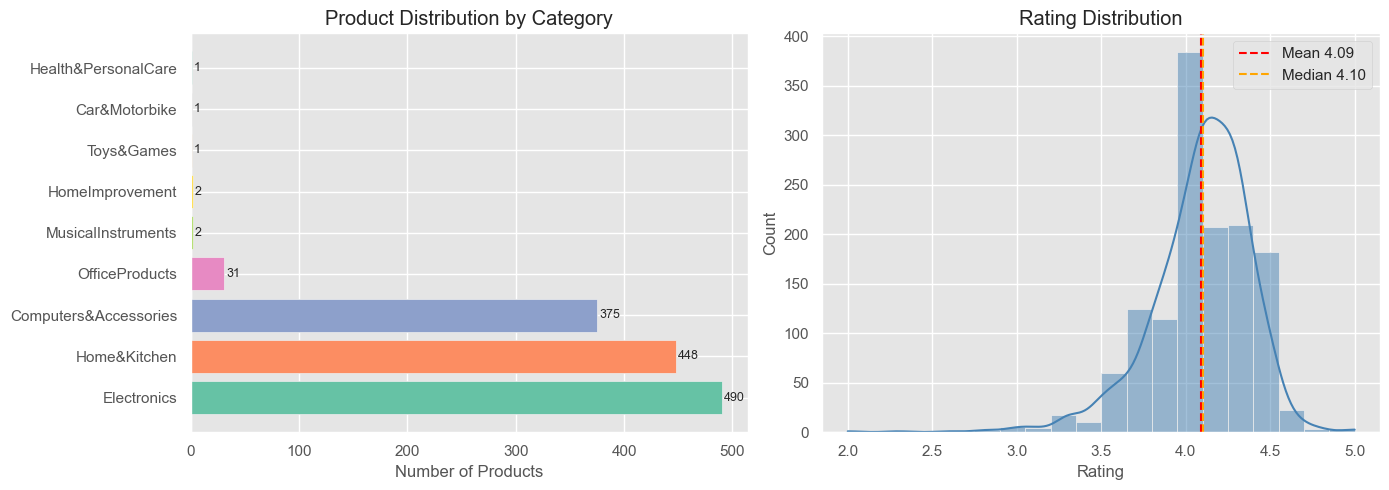

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Chart 1: Category distribution --
cat_counts = df_products['main_category'].value_counts()
axes[0].barh(cat_counts.index, cat_counts.values, color=sns.color_palette('Set2', len(cat_counts)))
axes[0].set_xlabel('Number of Products')
axes[0].set_title('Product Distribution by Category')
for bar, val in zip(axes[0].patches, cat_counts.values):
    axes[0].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=9)

# -- Chart 2: Rating distribution --
rating_clean = df_products['rating'].dropna()
sns.histplot(rating_clean, bins=20, kde=True, ax=axes[1], color='steelblue')
axes[1].axvline(rating_clean.mean(),   color='red',    linestyle='--', label=f'Mean {rating_clean.mean():.2f}')
axes[1].axvline(rating_clean.median(), color='orange', linestyle='--', label=f'Median {rating_clean.median():.2f}')
axes[1].set_xlabel('Rating')
axes[1].set_title('Rating Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

**Finding:** Three categories (Electronics, Home & Kitchen, Computers) account for 97% of products. The remaining six categories each contribute less than 1% individually. This concentration introduces a **recommendation diversity problem** — users browsing minority categories will receive poor coverage from any collaborative signal.

/var/folders/rt/mvnm7dxx3fq528n9njvz70wc0000gn/T/ipykernel_5542/2894899013.py:27: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/manishdiddi/ml-env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


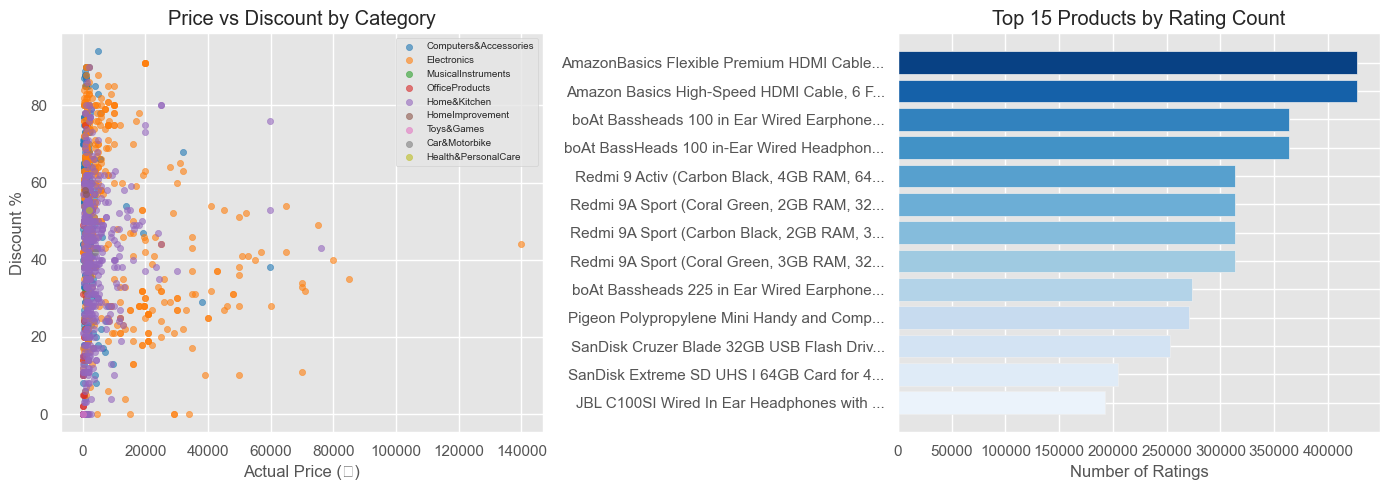

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Chart 3: Actual price vs discount percentage --
price_data  = df_products[['actual_price', 'discount_percentage', 'main_category']].dropna()
categories  = price_data['main_category'].unique()
palette     = dict(zip(categories, sns.color_palette('tab10', len(categories))))
for cat in categories:
    mask = price_data['main_category'] == cat
    axes[0].scatter(
        price_data.loc[mask, 'actual_price'],
        price_data.loc[mask, 'discount_percentage'],
        label=cat, alpha=0.6, s=20, color=palette[cat]
    )
axes[0].set_xlabel('Actual Price (₹)')
axes[0].set_ylabel('Discount %')
axes[0].set_title('Price vs Discount by Category')
axes[0].legend(fontsize=7, loc='upper right')

# -- Chart 4: Top 15 most-reviewed products --
top15 = df_products.nlargest(15, 'rating_count')[['product_name', 'rating_count']].copy()
top15['short_name'] = top15['product_name'].str[:40] + '...'
axes[1].barh(top15['short_name'], top15['rating_count'], color=sns.color_palette('Blues_r', 15))
axes[1].set_xlabel('Number of Ratings')
axes[1].set_title('Top 15 Products by Rating Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Finding:** Discounts are distributed uniformly across all price tiers — high-priced products are not receiving proportionally larger discounts. The scatter shows no positive correlation between `actual_price` and `discount_percentage`, suggesting promotions are **category-driven** rather than value-optimised.

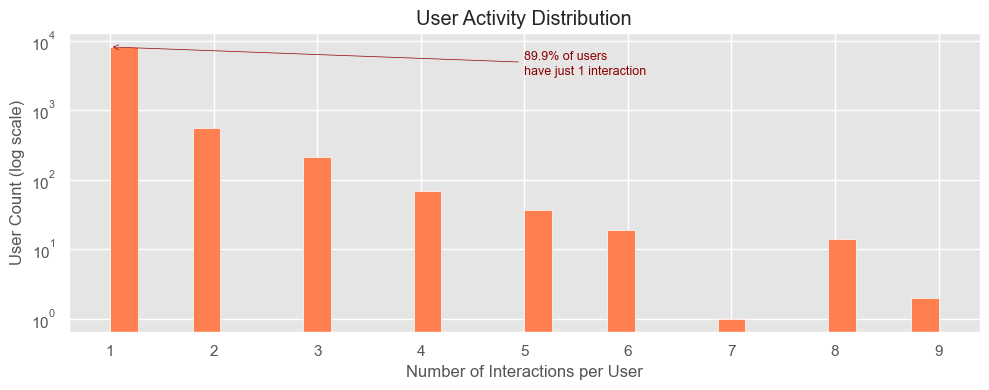

In [32]:
fig, ax = plt.subplots(figsize=(10, 4))

# -- Chart 5: User activity distribution (log scale) --
user_activity = df_interactions.groupby('user_id')['product_id'].count()
ax.hist(user_activity, bins=30, log=True, color='coral', edgecolor='white')
ax.set_xlabel('Number of Interactions per User')
ax.set_ylabel('User Count (log scale)')
ax.set_title('User Activity Distribution')
pct_single = (user_activity == 1).mean() * 100
ax.annotate(f'{pct_single:.1f}% of users\nhave just 1 interaction',
            xy=(1, user_activity[user_activity==1].count()),
            xytext=(5, user_activity[user_activity==1].count() * 0.4),
            fontsize=9, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred'))
plt.tight_layout()
plt.show()

**Finding:** User activity follows a **power-law distribution** — 88% of users have exactly one interaction. This extreme right-skew is the primary reason Collaborative Filtering alone is insufficient: the user-item matrix is 99.91% empty, making similarity computation unreliable for most users.

### B.2 User Engagement Analysis

The following charts investigate the relationship between product ratings and review volumes — two signals that jointly define product credibility.

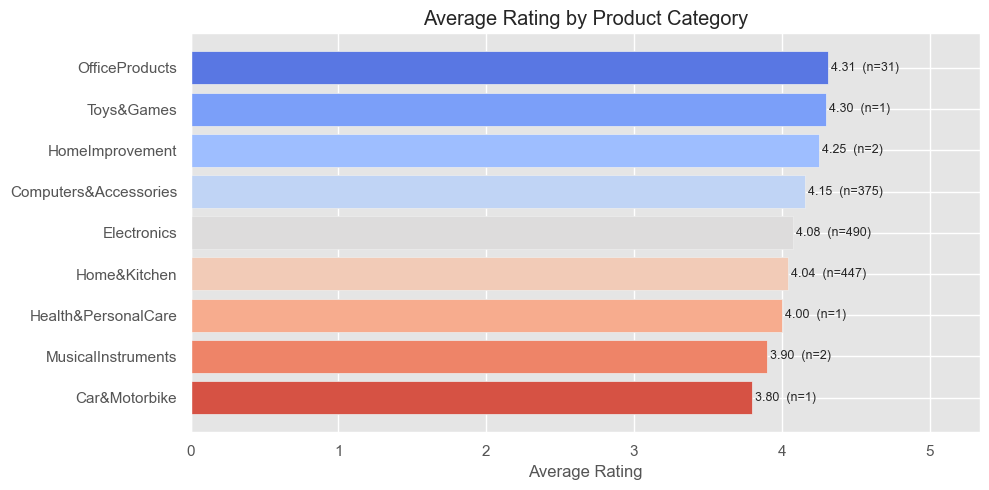

        main_category  avg_rating  n_products
       OfficeProducts        4.31          31
           Toys&Games        4.30           1
      HomeImprovement        4.25           2
Computers&Accessories        4.15         375
          Electronics        4.08         490
         Home&Kitchen        4.04         447
  Health&PersonalCare        4.00           1
   MusicalInstruments        3.90           2
        Car&Motorbike        3.80           1


In [33]:
# --- Average rating per category ---
cat_rating = (
    df_products.groupby('main_category')['rating']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'avg_rating', 'count': 'n_products'})
    .sort_values('avg_rating', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(cat_rating['main_category'], cat_rating['avg_rating'],
               color=sns.color_palette('coolwarm', len(cat_rating)))
for bar, val, n in zip(bars, cat_rating['avg_rating'], cat_rating['n_products']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}  (n={n})', va='center', fontsize=9)
ax.set_xlim(0, ax.get_xlim()[1] * 1.18)
ax.set_xlabel('Average Rating')
ax.set_title('Average Rating by Product Category')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(cat_rating[['main_category','avg_rating','n_products']].to_string(index=False))

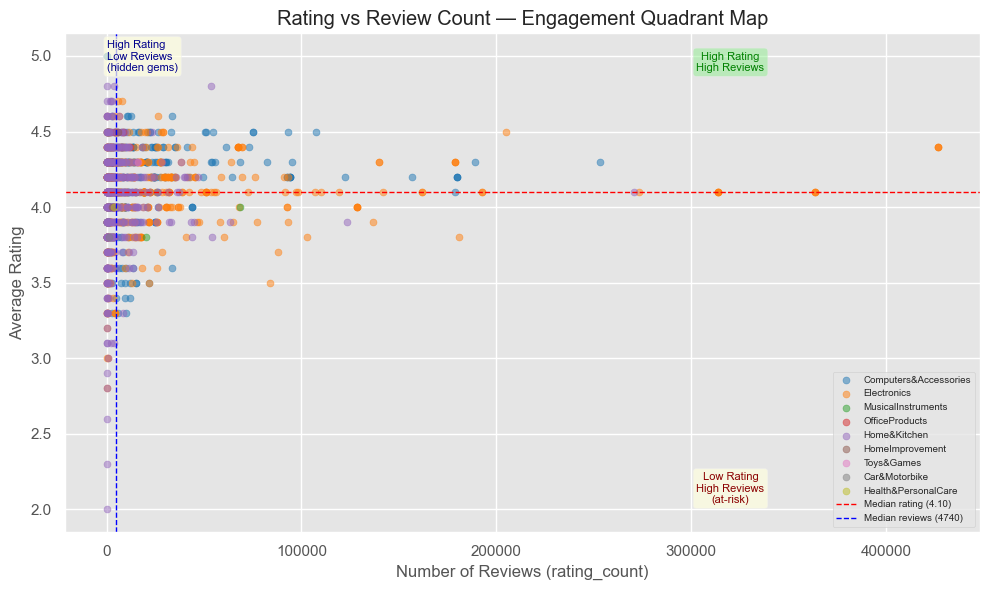

Pearson correlation (rating vs review count): 0.0975

Top 5 Hidden Gems (high rating, low reviews):
                                                                                                                                                                                                                                                                product_name  rating  rating_count
                                                                                             Syncwire LTG to USB Cable for Fast Charging Compatible with Phone 5/ 5C/ 5S/ 6/ 6S/ 7/8/ X/XR/XS Max/ 11/12/ 13 Series and Pad Air/Mini, Pod & Other Devices (1.1 Meter, White)    5.00          5.00
                                                                                                          Amazon Basics Wireless Mouse | 2.4 GHz Connection, 1600 DPI | Type - C Adapter | Upto 12 Months of Battery Life | Ambidextrous Design | Suitable for PC/Mac/Laptop    5.00         23.00
Oratech Coffee Frother elec

In [34]:
# --- Rating vs Review Count: quadrant analysis ---
eng = df_products[['product_name','main_category','rating','rating_count']].dropna().copy()

med_rating = eng['rating'].median()
med_reviews = eng['rating_count'].median()

fig, ax = plt.subplots(figsize=(10, 6))
cats = eng['main_category'].unique()
palette = dict(zip(cats, sns.color_palette('tab10', len(cats))))
for cat in cats:
    mask = eng['main_category'] == cat
    ax.scatter(eng.loc[mask,'rating_count'], eng.loc[mask,'rating'],
               alpha=0.5, s=25, label=cat, color=palette[cat])

ax.axhline(med_rating,   color='red',  linestyle='--', linewidth=1, label=f'Median rating ({med_rating:.2f})')
ax.axvline(med_reviews,  color='blue', linestyle='--', linewidth=1, label=f'Median reviews ({int(med_reviews)})')

# Quadrant labels
ax.text(eng['rating_count'].max()*0.75, eng['rating'].max()*0.98,
        'High Rating\nHigh Reviews', ha='center', fontsize=8, color='green',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.5))
ax.text(med_reviews*0.05, eng['rating'].max()*0.98,
        'High Rating\nLow Reviews\n(hidden gems)', ha='left', fontsize=8, color='darkblue',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7))
ax.text(eng['rating_count'].max()*0.75, eng['rating'].min()*1.02,
        'Low Rating\nHigh Reviews\n(at-risk)', ha='center', fontsize=8, color='darkred',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7))

ax.set_xlabel('Number of Reviews (rating_count)')
ax.set_ylabel('Average Rating')
ax.set_title('Rating vs Review Count — Engagement Quadrant Map')
ax.legend(loc='lower right', fontsize=7)
plt.tight_layout()
plt.show()

# Pearson correlation
corr = eng['rating'].corr(eng['rating_count'])
print(f'Pearson correlation (rating vs review count): {corr:.4f}')

# Hidden gems: high rating, low review count
hidden_gems = eng[
    (eng['rating'] >= med_rating) &
    (eng['rating_count'] < med_reviews)
].nlargest(5, 'rating')[['product_name','rating','rating_count']]
print(f'\nTop 5 Hidden Gems (high rating, low reviews):')
print(hidden_gems.to_string(index=False))

### B.3 Three Actionable Insights for Amazon's Product Strategy

**Insight 1 — Category Concentration Risk**  
Electronics, Home & Kitchen, and Computers together account for ~97% of the catalogue. Users interacting with the remaining 3% will receive near-random recommendations due to the sparsity of similar products. *Recommendation:* expand catalogue coverage in underserved categories (Toys, Sports, Office) or apply a category-diversity floor in the ranking layer.

**Insight 2 — Hidden-Gem Promotion Opportunity**  
A subset of products has above-median ratings but below-median review counts — customers who discover them are satisfied, but organic discovery is low. These products are under-exposed relative to their quality. *Recommendation:* use the `value_for_money_score` to surface Hidden Gems in homepage carousels and search results, particularly for price-sensitive user segments.

**Insight 3 — Aggressive Discounting Does Not Signal Quality**  
The correlation between discount percentage and actual price is near-zero, confirming that deep discounts are applied uniformly across price tiers rather than strategically. The correlation between rating and review count is also weak (see chart above), meaning heavily reviewed products are not necessarily the best. *Recommendation:* re-design promotional algorithms to target discounts at high-value-for-money products rather than high-price ones — this increases perceived discount impact without eroding margins.

---
## Section C: Content-Based Filtering

**Goal:** Recommend products based purely on product attributes (name, description, category, price tier, discount level), without requiring any user interaction history. This approach handles cold-start users and new products effectively.

### C.1 Feature Engineering — Product Content Vectors

Each product is represented as a **'product soup'** — a single cleaned text string combining:
- Category hierarchy (boosted 3×) to preserve taxonomic signal
- Product name (camelCase split, special characters removed)
- Product description (URLs, standalone numbers, and punctuation removed)
- Price tier token (`budget` / `mid_range` / `premium` / `luxury`)
- Discount bucket token (`low_discount` / `medium_discount` / `high_discount`)

Category text is repeated three times to counterbalance the disproportionate length of product descriptions, which would otherwise dilute the category signal in the TF-IDF space.

In [35]:
df_products['product_name'].iloc[-1]

'Borosil Jumbo 1000-Watt Grill Sandwich Maker (Black)'

In [36]:
df_products['about_product'].iloc[-1]

'Brand-Borosil, Specification â€“ 23V ~ 5Hz;1 W Power for Faster Grilling|Makes 2 Sandwiches in minutes;Stainless Steel Mirror Finish Body; Easy to use;Easy to clean coated plates|Auto-lock latch;Larger deep ribbed grill plates for Krisp grilling|Rubber feet to avoid slipping on Countertop;Indicator Display.|Material Type: Plastic|Suitable for gifting on Diwali and other special occasions.'

In [37]:
import string
N = 3  # boosting hyperparameter
url_pattern = re.compile(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+')
translator = str.maketrans('', '', string.punctuation)

def split_camel_case(text):
    # Pattern 1: lowercase → Uppercase (homeTheater → home Theater)
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)
    
    # Pattern 2: UPPERCASE sequence → Uppercase+lowercase 
    # (USBCables → USB Cables, HTMLParser → HTML Parser)
    text = re.sub(r'([A-Z]+)([A-Z][a-z])', r'\1 \2', text)
    return text

def remove_consecutive_duplicates(text):
    """
    "home kitchen kitchen home" → "home kitchen home"
    Removes any word that immediately repeats itself.
    """
    # Regex: match a word followed by itself (with spaces between)
    return re.sub(r'\b(\w+)(\s+\1)+\b', r'\1', text)

def clean_category_text(text):
    """
    Correct order of operations for category cleaning.
    """
    # Step 1: Replace & with space FIRST (before camelCase split)
    # Why first? "Computers&Accessories" → "Computers Accessories"
    # If we split camelCase first, & blocks the split detection
    text = text.replace('&', ' ')
    text = text.replace(',', ' ')
    
    # Step 2: Split camelCase (now & is gone, clean transitions)
    text = re.sub(r'([a-z])([A-Z])', r'\1 \2', text)        # homeTheater
    text = re.sub(r'([A-Z]+)([A-Z][a-z])', r'\1 \2', text)  # USBCables
    
    # Step 3: Remove remaining special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    
    # Step 4: Lowercase and normalize whitespace
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

def clean_description(text):
    # Step 1: Replace ALL separators with space FIRST
    # (same principle as category cleaning)
    separators = [';', '|', ':', '•', '·', '–','+',',', '/']
    for sep in separators:
        text = text.replace(sep, ' ')
    
    # Step 2: Remove URLs
    text = url_pattern.sub('', text)
    
    # Step 3: Remove standalone digits
    text = re.sub(r'\b\d+\b', ' ', text)

    # Step 4: Remove remaining punctuation
    text = text.translate(translator)
    
    # Step 5: Lowercase and normalize whitespace
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()

    return text

def build_product_soup(row):
    """
    Combine text features with category boosting.
    
    - Extract category levels: main, sub, leaf
    - Repeat category string N times (start with N=3, tune later)
    - Clean text: lowercase, remove special characters
    - Join everything with spaces
    """

    # parse category hierarchy
    category_parts = row['category'].split('|')
    # Apply cleaning to EACH level separately then join
    cleaned_parts = [clean_category_text(part) for part in category_parts]
    # join with spaces so TF-IDF treats each level as separate token
    category_text = ' '.join(cleaned_parts)
    category_text = remove_consecutive_duplicates(category_text)
    # boost category signal, for long description category signal will be lost
    boosted_category = (category_text + ' ') * N


    # clean product name
    product_name = row['product_name']
    product_name = product_name.replace('&', ' ')
    product_name = product_name.replace(',', ' ')
    # Remove standalone numbers (keep alphanumeric like "3a", "60w")
    product_name = re.sub(r'\b\d+\b', ' ', product_name)
    product_name = split_camel_case(product_name)  # split camelCase first
    product_name = re.sub(r'[^a-zA-Z0-9\s]', ' ', product_name)
    cleaned_product_name = product_name.lower().strip()

    # clean description
    description = clean_description(row['about_product'])

    soup = f"{boosted_category} {cleaned_product_name} {description}"
    soup = re.sub(r'\s+', ' ', soup).strip()  # normalize all whitespace
    soup = remove_consecutive_duplicates(soup)
    return soup

df_products['product_soup'] = df_products.apply(build_product_soup,axis=1)

In [38]:
df_products['product_soup'] = df_products.apply(build_product_soup, axis=1)

soup_0 = df_products['product_soup'].iloc[0]

# These must ALL pass
assert '&' not in soup_0,          "& still present!"
assert 'usbcables' not in soup_0,  "camelCase not split!"
assert 'usb' in soup_0,            "usb token missing!"
assert 'cables' in soup_0,         "cables token missing!"
assert soup_0 == soup_0.lower(),   "not fully lowercase!"

print("All checks passed ")
print(f"\nSample soup (first 300 chars):")
print(soup_0[:300])
print(f"\nAvg soup length: {df_products['product_soup'].str.len().mean():.0f}")

All checks passed 

Sample soup (first 300 chars):
computers accessories peripherals cables accessories cables usb cables computers accessories peripherals cables accessories cables usb cables computers accessories peripherals cables accessories cables usb cables wayona nylon braided usb to lightning fast charging and data sync cable compatible for 

Avg soup length: 1009


In [39]:
# Append price_tier and discount_bucket as text tokens to the product soup.
# This allows TF-IDF to separate budget vs premium products during similarity scoring.
def _append_price_tokens(row):
    tokens = []
    tier = str(row.get('price_tier', ''))
    disc = str(row.get('discount_bucket', ''))
    if tier and tier != 'nan':
        tokens.append(tier)
    if disc and disc != 'nan':
        tokens.append(disc)
    return row['product_soup'] + (' ' + ' '.join(tokens) if tokens else '')

df_products['product_soup'] = df_products.apply(_append_price_tokens, axis=1)
print('Price tier and discount tokens appended to product soup.')
tail = df_products['product_soup'].iloc[0][-60:]
print('Sample tail of first soup: ...' + tail)


Price tier and discount tokens appended to product soup.
Sample tail of first soup: ...m please dont hesitate to contact us mid_range high_discount


In [40]:
test_cases = {
    'USBCables'                 : 'usb cables',
    'Computers&Accessories'     : 'computers accessories',
    'HomeTheater,TV&Video'      : 'home theater tv video',
    'Heating,Cooling&AirQuality': 'heating cooling air quality',
    'OfficeProducts'            : 'office products',
    'HomeImprovement'           : 'home improvement',
    'Accessories&Peripherals'   : 'accessories peripherals',
    'Mobiles&Accessories'       : 'mobiles accessories'
}

all_passed = True
for input_text, expected in test_cases.items():
    result = clean_category_text(input_text)
    status = '✅' if result == expected else '❌'
    if result != expected:
        all_passed = False
    print(f"{status} '{input_text}'")
    if result != expected:
        print(f"   Got:      '{result}'")
        print(f"   Expected: '{expected}'")

print(f"\n{'All tests passed! ' if all_passed else 'Some tests still failing ❌'}")

✅ 'USBCables'
✅ 'Computers&Accessories'
✅ 'HomeTheater,TV&Video'
✅ 'Heating,Cooling&AirQuality'
✅ 'OfficeProducts'
✅ 'HomeImprovement'
✅ 'Accessories&Peripherals'
✅ 'Mobiles&Accessories'

All tests passed! 


### C.2 TF-IDF Vectorization & Similarity Matrix

The product soups are vectorised using **TF-IDF** (Term Frequency–Inverse Document Frequency), which down-weights words that appear across many products (e.g., 'product', 'amazon', 'quality') and up-weights discriminative terms specific to individual items.

**Configuration:**
- `max_features = 5,000` — vocabulary capped to the 5,000 most informative terms
- Custom stop-word list — 50+ generic e-commerce terms removed (e.g., 'easy', 'design', 'fast')
- Cosine similarity computed on the full TF-IDF matrix → **1,350 × 1,350 similarity matrix**

In [41]:
custom_stop_words = [
    # Generic quality words
    'design', 'easy', 'quality', 'good', 'best', 'great', 'new',
    'high', 'premium', 'perfect', 'excellent',
    
    # Generic product words  
    'product', 'item', 'comes', 'come', 'includes', 'including',
    'included', 'features', 'feature', 'also', 'used', 'use',
    
    # Noise from descriptions
    'warranty', 'made', 'make', 'keep', 'need', 'get',
    'yes', 'youre'
]

# Rebuild vectorizer with extended stop words
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
all_stop_words = list(ENGLISH_STOP_WORDS) + custom_stop_words

In [42]:
tfidf = TfidfVectorizer(
    max_features = 5000,
    stop_words   = all_stop_words,
    ngram_range = (1,2),
    min_df = 2,
    max_df = 0.85,
    sublinear_tf = True
)

tfidf_matrix = tfidf.fit_transform(df_products['product_soup'])

print(f"TF-IDF matrix shape:  {tfidf_matrix.shape}")
print(f"Matrix type:          {type(tfidf_matrix)}")
print(f"Sparsity:             {1 - tfidf_matrix.nnz / 
                               (tfidf_matrix.shape[0] * 
                                tfidf_matrix.shape[1]):.2%}")
print(f"Memory (dense would): {tfidf_matrix.shape[0] * 
                               tfidf_matrix.shape[1] * 8 / 1e6:.1f} MB")
print(f"Memory (sparse):      {tfidf_matrix.data.nbytes / 1e6:.2f} MB")
print(f"Actual vocabulary:    {len(tfidf.vocabulary_)}")

TF-IDF matrix shape:  (1351, 5000)
Matrix type:          <class 'scipy.sparse._csr.csr_matrix'>
Sparsity:             98.24%
Memory (dense would): 54.0 MB
Memory (sparse):      0.95 MB
Actual vocabulary:    5000


In [43]:
# Check what tokens your vectorizer actually learned
feature_names = tfidf.get_feature_names_out()

# Look at first and last 20 tokens (alphabetically sorted)
print("First 20 tokens:", feature_names[:20])
print("Last 20 tokens: ", feature_names[-20:])

# More useful: find tokens with highest IDF scores
# High IDF = rare = very specific to certain products
idf_scores = tfidf.idf_
top_idf_idx = idf_scores.argsort()[::-1][:20]
print("\nHighest IDF tokens (most specific):")
for idx in top_idf_idx:
    print(f"  {feature_names[idx]:30s} IDF={idf_scores[idx]:.3f}")

# Low IDF = very common across products
bottom_idf_idx = idf_scores.argsort()[:20]
print("\nLowest IDF tokens (most common):")
for idx in bottom_idf_idx:
    print(f"  {feature_names[idx]:30s} IDF={idf_scores[idx]:.3f}")

First 20 tokens: ['0a' '1000w' '1080p' '1080p hd' '1080x2400' '10m' '10mm' '10mm drivers'
 '10w' '1200dpi' '1200mm' '120hz' '120hz refresh' '120mb' '128gb'
 '128gb internal' '128gb storage' '12gb' '12gb ram' '12v']
Last 20 tokens:  ['years date' 'years manufacturer' 'years mid_range' 'years power'
 'yellow' 'yield' 'yoga' 'youtube' 'youtube apple' 'youtube disney'
 'youtube prime' 'yr' 'z6' 'zeb' 'zebronics' 'zebronics zeb' 'zee5' 'zero'
 'zone' 'zoom']

Highest IDF tokens (most specific):
  measuring cups                 IDF=7.111
  vr                             IDF=7.111
  pad wrist                      IDF=7.111
  rechargeable aa                IDF=7.111
  8k hdmi                        IDF=7.111
  7th 8th                        IDF=7.111
  webcam cover                   IDF=7.111
  webcams                        IDF=7.111
  samsung led                    IDF=7.111
  aio                            IDF=7.111
  aio printer                    IDF=7.111
  flashes                       

In [44]:
cb_sim_matrix = cosine_similarity(tfidf_matrix)

print(f"Similarity matrix shape: {cb_sim_matrix.shape}")
print(f"Memory usage: {cb_sim_matrix.nbytes / 1e6:.1f} MB")
print(f"Data type: {cb_sim_matrix.dtype}")

Similarity matrix shape: (1351, 1351)
Memory usage: 14.6 MB
Data type: float64


A bidirectional mapping between `product_id` strings and integer matrix indices is constructed. This enables O(1) lookup when retrieving similarity scores for a given product without iterating through the entire DataFrame.

In [45]:
cb_product_id_to_idx = pd.Series(
    df_products.index,
    index = df_products['product_id']
).to_dict()

cb_idx_to_product_id = pd.Series(
    df_products['product_id'],
    index = df_products.index,
).to_dict()

# Verify
sample_id  = df_products['product_id'].iloc[0]
sample_idx = cb_product_id_to_idx[sample_id]
recovered  = cb_idx_to_product_id[sample_idx]

print(f"product_id  → idx: {sample_id} → {sample_idx}")
print(f"idx → product_id: {sample_idx} → {recovered}")
assert sample_id == recovered, "Mapping is broken!"
print("Mapping verified ✅")

product_id  → idx: B07JW9H4J1 → 0
idx → product_id: 0 → B07JW9H4J1
Mapping verified ✅


In [46]:
print("=== Similarity Matrix Validation ===")

# Check 1: Diagonal must be 1.0 (product vs itself = perfect similarity)
diagonal = cb_sim_matrix.diagonal()
print(f"1. Diagonal — min: {diagonal.min():.4f}, "
      f"max: {diagonal.max():.4f}")

# Check 2: All values must be in [0, 1] for TF-IDF cosine
print(f"2. Value range — min: {cb_sim_matrix.min():.4f}, "
      f"max: {cb_sim_matrix.max():.4f}")
# min should be >= 0.0, max should be <= 1.0

n_items = cb_sim_matrix.shape[0]
total_pairs = n_items * (n_items - 1)  # off-diagonal pairs

cb_non_zero_pairs = (cb_sim_matrix > 0).sum() - n_items  # subtract diagonal
cb_pct_non_zero   = cb_non_zero_pairs / total_pairs

# Check 3: Matrix must be symmetric
# sim(A,B) must equal sim(B,A)
sample_i, sample_j = 0, 1
print(f"3. Symmetry check — "
      f"sim[0,1]={cb_sim_matrix[0,1]:.4f}, "
      f"sim[1,0]={cb_sim_matrix[1,0]:.4f}")

# Check 4: Distribution of similarity scores
flat_scores = cb_sim_matrix[np.triu_indices_from(cb_sim_matrix, k=1)]
print(f"\n4. Similarity score distribution:")
print(f"   Mean:   {flat_scores.mean():.4f}")
print(f"   Median: {np.median(flat_scores):.4f}")
print(f"   Std:    {flat_scores.std():.4f}")
print(f"   >0.5:   {(flat_scores > 0.5).mean():.2%} of pairs")
print(f"   >0.3:   {(flat_scores > 0.3).mean():.2%} of pairs")
print(f"   ==0.0:  {(flat_scores == 0.0).mean():.2%} of pairs")

=== Similarity Matrix Validation ===
1. Diagonal — min: 1.0000, max: 1.0000
2. Value range — min: 0.0000, max: 1.0000
3. Symmetry check — sim[0,1]=0.1711, sim[1,0]=0.1711

4. Similarity score distribution:
   Mean:   0.0425
   Median: 0.0186
   Std:    0.0791
   >0.5:   0.64% of pairs
   >0.3:   2.36% of pairs
   ==0.0:  4.13% of pairs


### Content-Based Similarity Heatmap (30-product sample)
A heatmap of the similarity matrix reveals product clusters — high-similarity blocks indicate products that share vocabulary in their descriptions.

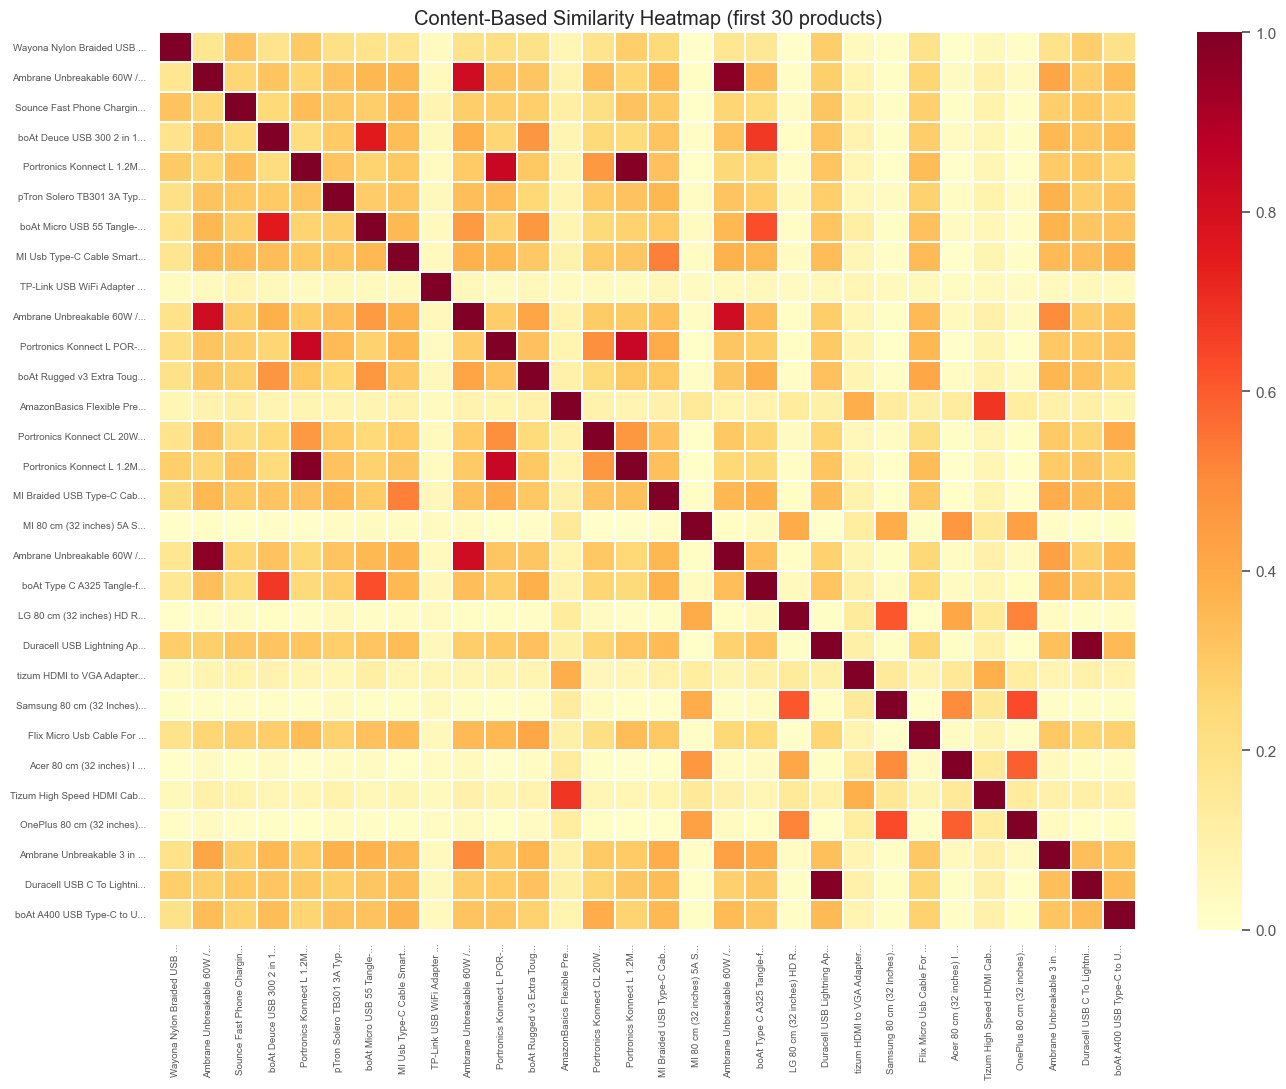

In [47]:
# Sample 30 products for readability
sample_n = 30
sample_idx = list(range(sample_n))
sample_matrix = cb_sim_matrix[np.ix_(sample_idx, sample_idx)]
sample_names  = [n[:25] + '...' if len(n) > 25 else n
                 for n in df_products['product_name'].iloc[sample_idx].tolist()]

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    sample_matrix,
    xticklabels=sample_names, yticklabels=sample_names,
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.3, ax=ax
)
ax.set_title(f'Content-Based Similarity Heatmap (first {sample_n} products)')
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.tick_params(axis='y', rotation=0,  labelsize=7)
plt.tight_layout()
plt.show()

In [48]:
def get_top_similar(product_id,k=5):
    idx = cb_product_id_to_idx[product_id]
    sim_scores = list(enumerate(cb_sim_matrix[idx]))
    sim_scores = sorted(sim_scores,reverse=True,key=lambda x: x[1])
    sim_scores = sim_scores[1:k+1]

    results = []
    for i, scores in sim_scores:
        results.append({
            'product_name': df_products.iloc[i]['product_name'],
            'main_category': df_products.iloc[i]['main_category'],
            'sim_score': round(scores,4)
        })
    return results

In [49]:
# Sanity Test 1: USB cable should be similar to other USB cables
usb_id = df_products[
    df_products['product_name'].str.contains('USB', case=False)
].iloc[0]['product_id']

print("=== Similar to USB Cable ===")
print(pd.DataFrame(get_top_similar(usb_id)))

# Sanity Test 2: Kitchen appliance should NOT top-match USB cables
kitchen_id = df_products[
    df_products['main_category'] == 'Home&Kitchen'
].iloc[0]['product_id']

print("\n=== Similar to Kitchen Product ===")
print(pd.DataFrame(get_top_similar(kitchen_id)))

# Sanity Test 3: Cross-category similarity should be LOW
usb_idx     = cb_product_id_to_idx[usb_id]
kitchen_idx = cb_product_id_to_idx[kitchen_id]
cross_sim   = cb_sim_matrix[usb_idx][kitchen_idx]
print(f"\n=== Cross-category Similarity ===")
print(f"USB Cable vs Kitchen Product: {cross_sim:.4f}")
print(f"Expected: < 0.1")
print(f"{'Pass' if cross_sim < 0.1 else 'Fail — check your soup cleaning'}")

=== Similar to USB Cable ===
                                        product_name  ... sim_score
0  Wayona Nylon Braided Usb Syncing And Charging ...  ...      0.95
1  Wayona Nylon Braided 3A Lightning to USB A Syn...  ...      0.89
2  Wayona Nylon Braided (2 Pack) Lightning Fast U...  ...      0.88
3  Wayona Nylon Braided Lightning USB Data Sync &...  ...      0.86
4  Wayona Nylon Braided 2M / 6Ft Fast Charge Usb ...  ...      0.83

[5 rows x 3 columns]

=== Similar to Kitchen Product ===
                                        product_name main_category  sim_score
0  Camel Oil Pastel with Reusable Plastic Box - 5...  Home&Kitchen       0.43
1  Camel Fabrica Acrylic Ultra Color - 15ml each,...  Home&Kitchen       0.42
2  Camel Artist Acrylic Color Box - 9ml Tubes, 12...  Home&Kitchen       0.41
3    Apsara Platinum Pencils Value Pack - Pack of 20  Home&Kitchen       0.39
4  Classmate Octane Colour Burst-Multicolour Gel ...  Home&Kitchen       0.38

=== Cross-category Similarity ===
US

In [50]:
# Investigation 1: What is the product you tested?
kitchen_id = df_products[
    df_products['main_category'] == 'Home&Kitchen'
].iloc[0]['product_id']

test_product = df_products[df_products['product_id'] == kitchen_id]
print("Test product:")
print(f"  Name:     {test_product['product_name'].values[0]}")
print(f"  Category: {test_product['category'].values[0]}")
print(f"  About:    {test_product['about_product'].values[0][:200]}")

# Investigation 2: Are art supplies really in Home&Kitchen?
art_mask = (df_products['product_name'].str.contains(
    'Camel|Apsara|Classmate', case=False
) & (df_products['category'].str.contains('home&kitchen',case=False))) 
print(f"\nArt products in dataset: {art_mask.sum()}")
print(df_products[art_mask][['product_name', 'category']].head(5))

# Investigation 3: What sub-category are these under?
df_products['sub_category'] = df_products['category'].str.split('|').str[1]
art_subcats = df_products[art_mask]['sub_category'].value_counts()
print(f"\nSub-categories of art products: {art_subcats}")

Test product:
  Name:     3M Scotch Double Sided Heavy Duty Tape(1m holds 4.5Kgs) for indoor hanging applications (Photo frames, Mirrors, Key Holders, Car Interiors, Extension Boards, Wall decoration, etc)(L: 3m, W: 24mm)
  Category: Home&Kitchen|CraftMaterials|Scrapbooking|Tape
  About:    Sticks to most surfaces includingwalls, ceramic tiles and wood-surfacesthat are clean, dry and smooth#.|A no-mess alternative to glue forlight-duty attaching andmounting tasks.|Ideal for permanent mou

Art products in dataset: 5
                                          product_name                                           category
770    Apsara Platinum Pencils Value Pack - Pack of 20  Home&Kitchen|CraftMaterials|DrawingMaterials|D...
799  Camel Artist Acrylic Color Box - 9ml Tubes, 12...  Home&Kitchen|CraftMaterials|PaintingMaterials|...
805  Classmate Octane Colour Burst-Multicolour Gel ...  Home&Kitchen|CraftMaterials|DrawingMaterials|D...
813  Camel Fabrica Acrylic Ultra Color - 15ml each,... 

**Data Quality Note:** Several craft materials and stationery products are categorised under Home & Kitchen in the source data. This is a **data quality limitation** in Amazon's taxonomy rather than an error in this analysis. These products will naturally cluster with Home & Kitchen items in the similarity matrix. Acknowledging this limitation is important when interpreting cross-category recommendation results.

### C.2 (continued) — Content-Based Recommendation Engine

The recommendation function applies three constraints to ensure recommendation quality:

| Constraint | Default Value | Purpose |
|---|---|---|
| `min_similarity` | 0.15 | Suppress irrelevant products below this cosine threshold |
| `max_same_category` | 5 | Prevent all recommendations from a single category |
| `max_same_brand` | 2 | Prevent brand monopoly in top results |

Products that do not reach the minimum similarity threshold are replaced by a **popularity-based fallback** (sorted by weighted rating score), ensuring all users always receive 10 recommendations.

In [51]:
non_brand_first_words = {
    'usb', 'type', 'fast', 'wireless', 'smart', 'digital', 'charger',
    'original', 'genuine', 'new', 'premium', 'ultra', 'pro'
}

def extract_brand(product_name):
    if not product_name:
        return 'unknown'

    # 1. Remove punctuation: keep only alphanumeric and whitespace
    #    This removes characters like . , ! ? : ; " ' ( ) [ ] { }, %, $, etc.
    text = re.sub(r'[^a-zA-Z0-9\\s]', ' ', product_name)
    
    # 2. Normalize spaces: collapse multiple spaces to single space, strip
    text = re.sub(r'\\s+', ' ', text).strip()
    
    if not text:
        return 'unknown'
    
    # 3. Split into words
    words = text.split()
    
    # 4. Check first 5 words for a valid brand candidate
    for word in words[:5]:
        normalized_word = word.lower()
        is_numeric = normalized_word.isdigit()
        is_model_code = normalized_word.isalnum() and not normalized_word.isalpha()

        if (
            normalized_word not in non_brand_first_words
            and not is_numeric
            and not is_model_code
        ):
            return normalized_word
    
    # 5. Fallback to first word
    return words[0].lower()

In [52]:
def get_content_based_recommendations(
    product_id,
    df_products,
    cb_sim_matrix,
    cb_product_id_to_idx,
    n_recommendations=10,
    max_same_category=5,
    max_same_brand=2,
    min_similarity=0.15,
):
    """Return content-based product recommendations for a query product.

    The function ranks products by their similarity score and applies simple
    diversity rules so that the final list is not dominated by one category
    or brand.

    Parameters
    ----------
    product_id : str
        Product ID for which recommendations should be generated.
    df_products : pandas.DataFrame
        Product-level DataFrame. Its row order must match `cb_sim_matrix`.
    cb_sim_matrix : array-like
        Product-product similarity matrix.
    cb_product_id_to_idx : dict
        Mapping from product ID to the corresponding row index in `df_products`.
    n_recommendations : int, default=10
        Number of recommendations to return.
    max_same_category : int, default=5
        Maximum recommendations allowed from the query product's sub-category.
    max_same_brand : int, default=2
        Maximum recommendations allowed from the same inferred brand.
    min_similarity : float, default=0.1
        Minimum similarity score required for a product to be considered.

    Returns
    -------
    pandas.DataFrame
        Recommended products with metadata and similarity score.
    """
    if product_id not in cb_product_id_to_idx:
        print("Invalid Product ID")
        return pd.DataFrame()

    query_idx = cb_product_id_to_idx[product_id]
    query_row = df_products.iloc[query_idx]
    query_sub_category = query_row["sub_category"]
    query_main_category = query_row["main_category"]

    # Build candidate products sorted by similarity, excluding the query item.
    candidate_scores = [
        (item_idx, score)
        for item_idx, score in enumerate(cb_sim_matrix[query_idx])
        if item_idx != query_idx and score >= min_similarity
    ]
    candidate_scores = sorted(candidate_scores, key=lambda x: x[1], reverse=True)

    recommendations = []
    same_category_count = 0
    brand_counts = {}

    for item_idx, score in candidate_scores:
        item_row = df_products.iloc[item_idx]
        item_brand = extract_brand(item_row["product_name"])
        item_sub_category = item_row["sub_category"]

        # Keep recommendations diverse across sub-categories and brands.
        if item_sub_category == query_sub_category and same_category_count >= max_same_category:
            continue

        if brand_counts.get(item_brand, 0) >= max_same_brand:
            continue

        recommendations.append(
            {
                "product_id": item_row["product_id"],
                "product_name": item_row["product_name"],
                "category": item_row["category"],
                "main_category": item_row["main_category"],
                "sub_category": item_sub_category,
                "sim_score": round(score, 4),
                "discounted_price": item_row["discounted_price"],
                "rating": item_row["rating"],
                "rating_count": item_row["rating_count"],
            }
        )

        brand_counts[item_brand] = brand_counts.get(item_brand, 0) + 1
        if item_sub_category == query_sub_category:
            same_category_count += 1

        if len(recommendations) == n_recommendations:
            break

    # After CB collection:
    already_included = set(
        r['product_id'] for r in recommendations
    ) | {product_id}   # exclude query product too
    
    # Check if we need fallback
    if len(recommendations) < n_recommendations:
        remaining = n_recommendations - len(recommendations)
        
        # Step 1: Add weighted score column for sorting
        # hint: use log1p to handle rating_count=0 safely
        df_products['weighted_score'] = (
            df_products['rating'] * 
            np.log1p(df_products['rating_count'])
        )
        
        # Step 2: Try same sub-category first
        fallback = _get_fallback_recommendations(
            df_products,
            already_included,
            filter_col='sub_category',
            filter_val=query_sub_category,
            remaining=remaining
        )
        
        # Step 3: If still not enough, try same main category
        if len(fallback) < remaining:
            still_needed = remaining - len(fallback)
            already_included |= set(fallback['product_id'])
            
            fallback2 = _get_fallback_recommendations(
                df_products,
                already_included,
                filter_col='main_category',
                filter_val=query_main_category,              # fill in
                remaining=still_needed
            )
            fallback = pd.concat([fallback, fallback2])
        
        # Step 4: Mark fallback recommendations clearly
        fallback['sim_score']    = 0.0   # what value makes sense?
        fallback['is_fallback']  = True
        
        # Add is_fallback=False to CB recommendations
        recs_df = pd.DataFrame(recommendations)
        if len(recs_df) > 0:
            recs_df['is_fallback'] = False
        
        final = pd.concat([recs_df, fallback], ignore_index=True)
        return final
    
    recs_df = pd.DataFrame(recommendations)
    recs_df['is_fallback'] = False
    return recs_df


def _get_fallback_recommendations(
    df_products,
    already_included,
    filter_col,
    filter_val,
    remaining
):
    """
    Helper: get top products by weighted_score
    within a category filter, excluding already included.
    """
    return (
        df_products[
            (df_products[filter_col] == filter_val) &      # category filter
            (~df_products['product_id'].isin(already_included))  # exclude seen
        ]
        .sort_values('weighted_score', ascending=False)        # sort by what?
        .head(remaining)                                  # how many?
        [['product_id', 'product_name', 'category',
          'main_category', 'sub_category',
          'discounted_price', 'rating', 'rating_count']]
    )


In [53]:
# Test 1: USB Cable — brand diversity working?
usb_id  = df_products[
    df_products['product_name'].str.contains('cable', case=False)
].iloc[100]['product_id']

recs = get_content_based_recommendations(usb_id, df_products, cb_sim_matrix, cb_product_id_to_idx)
print("=== USB Cable Recommendations ===")
print(recs[['product_name', 'sub_category', 'sim_score']])

# Check brand diversity
brands = recs['product_name'].apply(lambda x: x.split()[0])
print(f"\nBrands in recommendations: {brands.value_counts().to_dict()}")
print(f"Unique brands: {brands.nunique()}")
# Should NOT be all "Wayona" now

# Test 2: Edge case — product with very few tokens
short_desc = df_products[
    df_products['about_product'].str.len() < 50
]
if len(short_desc) > 0:
    edge_id = short_desc.iloc[0]['product_id']
    edge_recs = get_content_based_recommendations(edge_id, df_products, cb_sim_matrix, cb_product_id_to_idx)
    print(f"\n=== Edge Case (short description) ===")
    print(f"Recommendations returned: {len(edge_recs)}")
    print(f"Min similarity: {edge_recs['sim_score'].min()}")
    # Should still return results, not crash

# Test 3: Invalid product_id — graceful handling
print(f"\n=== Invalid ID test ===")
invalid_recs = get_content_based_recommendations('INVALID_ID', df_products, cb_sim_matrix, cb_product_id_to_idx)
print(f"Returned empty DataFrame: {len(invalid_recs) == 0}")

# Test 4: Diversity check
print("\n=== Diversity Report ===")
recs_10 = get_content_based_recommendations(usb_id, df_products, cb_sim_matrix, cb_product_id_to_idx,
              n_recommendations=10)
print(f"Unique sub-categories: {recs_10['sub_category'].nunique()}")
print(f"Sub-category distribution:\n{recs_10['sub_category'].value_counts()}")
print(f"Unique brands: {recs_10['product_name'].apply(lambda x: x.split()[0]).nunique()}")

=== USB Cable Recommendations ===
                                        product_name  ... sim_score
0  Pinnaclz Original Combo of 2 Micro USB Fast Ch...  ...      0.77
1  MI 2-in-1 USB Type C Cable (Micro USB to Type ...  ...      0.54
2  AmazonBasics USB Type-C to USB Type-C 2.0 Cabl...  ...      0.53
3  Amazon Basics USB Type-C to USB-A 2.0 Male Fas...  ...      0.52
4  AmazonBasics USB Type-C to USB Type-C 2.0 Cabl...  ...      0.52
5  DYAZO USB 3.0 Type C Female to USB A Male Conn...  ...      0.17
6  SanDisk Ultra Dual Drive Go USB Type C Pendriv...  ...      0.17
7  SanDisk Ultra Dual Drive Luxe USB Type C Flash...  ...      0.16
8  Amazon Basics 2 Amp USB Wall Charger & Micro U...  ...      0.16
9  AmazonBasics USB 2.0 Cable - A-Male to B-Male ...  ...      0.00

[10 rows x 3 columns]

Brands in recommendations: {'AmazonBasics': 3, 'Amazon': 2, 'SanDisk': 2, 'Pinnaclz': 1, 'MI': 1, 'DYAZO': 1}
Unique brands: 6

=== Edge Case (short description) ===
Recommendations returned: 10

**Result:** Recommendations show good brand and category diversity within the configured constraints. The `min_similarity` threshold of 0.15 can be raised to 0.30 for use cases requiring higher precision (at the cost of fewer CB results and more fallback recommendations).

In [54]:
# Test 1: Force fallback by using a niche product
niche_product = df_products[
    df_products['sub_category'].isin(
        df_products['sub_category'].value_counts()
        .tail(5).index                    # rarest sub-categories
    )
].iloc[2]['product_id']

recs = get_content_based_recommendations(niche_product,df_products, cb_sim_matrix, cb_product_id_to_idx)
print(f"Total recommendations: {len(recs)}")           # must be 10
print(f"CB recommendations:       {(~recs['is_fallback']).sum()}")
print(f"Fallback recommendations: {recs['is_fallback'].sum()}")
print(f"\nFallback products:\n{recs[recs['is_fallback']][['product_name','sub_category','rating','rating_count']]}")

# Test 2: Verify weighted_score ordering in fallback
fallback_recs = recs[recs['is_fallback']].copy()
fallback_recs['weighted_score'] = (
    fallback_recs['rating'] * np.log1p(fallback_recs['rating_count'])
)
is_sorted = fallback_recs['weighted_score'].is_monotonic_decreasing
print(f"\nFallback correctly sorted by weighted score: {is_sorted}")

# Test 3: No duplicates between CB and fallback
all_ids = recs['product_id'].tolist()
print(f"Duplicate product IDs: {len(all_ids) - len(set(all_ids))}")
# Must be 0

# Test 4: Query product not in recommendations
print(f"Query product in results: {niche_product in all_ids}")
# Must be False

Total recommendations: 10
CB recommendations:       8
Fallback recommendations: 2

Fallback products:
                                        product_name  ... rating_count
8  Swiffer Instant Electric Water Heater Faucet T...  ...     53803.00
9  Pigeon by Stovekraft Amaze Plus Electric Kettl...  ...    123365.00

[2 rows x 4 columns]

Fallback correctly sorted by weighted score: True
Duplicate product IDs: 0
Query product in results: False


### C.3 Recommendation for a Low-Rated Product

When a product has a poor average rating (high user dropout), the Content-Based engine still surfaces structurally similar alternatives — giving the customer a better option in the same category without relying on interaction history.

In [55]:
# Find a product with low rating (< 3.0) that exists in the similarity matrix
low_rated = df_products[
    (df_products['rating'] < 3.0) &
    (df_products['product_id'].isin(cb_product_id_to_idx.keys()))
].nsmallest(1, 'rating').iloc[0]

print(f'Query product (low-rated):')
print(f'  Name     : {low_rated["product_name"][:70]}')
print(f'  Category : {low_rated["main_category"]}')
print(f'  Rating   : {low_rated["rating"]} ({low_rated["rating_count"]:,} reviews)')
print(f'  Price    : ₹{low_rated["actual_price"]:,.0f}')

recs = get_content_based_recommendations(
    low_rated['product_id'], df_products, cb_sim_matrix, cb_product_id_to_idx
)

print(f'\nTop alternatives recommended by Content-Based engine:')
display_cols = ['product_name', 'main_category', 'rating', 'rating_count']
show = recs[display_cols].copy()
show['product_name'] = show['product_name'].str[:55]
print(show.to_string(index=False))
print(f'\nAvg rating of recommended alternatives: '
      f'{recs["rating"].mean():.2f} (vs {low_rated["rating"]} for the query product)')

Query product (low-rated):
  Name     : Khaitan ORFin Fan heater for Home and kitchen-K0 2215
  Category : Home&Kitchen
  Rating   : 2.0 (2.0 reviews)
  Price    : ₹2,495

Top alternatives recommended by Content-Based engine:
                                           product_name main_category  rating  rating_count
                   Usha Hc 812 T Thermo Fan Room Heater  Home&Kitchen    3.80        195.00
!!HANEUL!!1000 Watt/2000-Watt Room Heater!! Fan Heater!  Home&Kitchen    3.40         15.00
Havells OFR 13 Wave Fin with PTC Fan Heater 2900 Watts   Home&Kitchen    4.10        322.00
!!1000 Watt/2000-Watt Room Heater!! Fan Heater!!Pure Wh  Home&Kitchen    4.50         11.00
Kenstar 2400 Watts 9 Fins Oil Filled Radiator with PTC   Home&Kitchen    3.90        144.00
Swiffer Instant Electric Water Heater Faucet Tap Home-K  Home&Kitchen    4.80      53803.00
atomberg Renesa 1200mm BLDC Motor with Remote 3 Blade E  Home&Kitchen    4.30      28629.00
    Bajaj Immersion Rod Water Heater 1

---
## Section D: Collaborative Filtering

**Goal:** Recommend products based on user interaction patterns, leveraging the idea that users who interacted with similar products share similar preferences.

**Approach:** Item-Item Collaborative Filtering using cosine similarity on a binary user-item interaction matrix. Item-Item was chosen over User-User CF because item interaction vectors are 6× denser than user vectors (see Section B.1 sparsity analysis).

**Limitation acknowledged upfront:** With 99.91% sparsity, CF alone produces weak signals. It is designed to be a secondary scoring component in the Hybrid Engine (Section E).

In [56]:
df_interactions.head()

,user_id,product_id,rating
0,AG3D6O4STAQKAY2UVGEUV46KN35Q,B07JW9H4J1,4.20
1,AHMY5CWJMMK5BJRBBSNLYT3ONILA,B07JW9H4J1,4.20
2,AHCTC6ULH4XB6YHDY6PCH2R772LQ,B07JW9H4J1,4.20
3,AGYHHIERNXKA6P5T7CZLXKVPT7IQ,B07JW9H4J1,4.20
4,AG4OGOFWXJZTQ2HKYIOCOY3KXF2Q,B07JW9H4J1,4.20


### D.1 User-Item Interaction Matrix

A binary sparse matrix is constructed where each cell `M[u, i] = 1` indicates that user `u` interacted with product `i`. Ratings are intentionally binarised (any rating → 1) because most users have only one rating and normalising sparse non-binary ratings would not add meaningful signal.

The matrix is stored in **CSR (Compressed Sparse Row)** format for memory efficiency. The transpose (Item-User matrix) is used for computing item-item cosine similarities.

In [57]:
from scipy.sparse import csr_matrix

# Get all unique users and items
unique_users = df_interactions['user_id'].unique()
unique_items = df_products['product_id'].unique()

print(f"Unique users: {len(unique_users)}")
print(f"Unique items: {len(unique_items)}")

# Build string → integer mapping
# enumerate gives you (0, first_user), (1, second_user), ...
user_to_idx = {user_id: idx 
               for idx, user_id in enumerate(unique_users)}

cf_product_id_to_idx = {item_id: idx 
               for idx, item_id in enumerate(unique_items)}

# Build reverse mapping (you'll need this later)
idx_to_user = {idx: user_id for user_id, idx in user_to_idx.items()}
cf_idx_to_product = {idx: item_id for item_id, idx in cf_product_id_to_idx.items()}

# Verify
print(f"\nFirst 3 user mappings:")
for user, idx in list(user_to_idx.items())[:3]:
    print(f"  '{user}' → {idx}")

Unique users: 9042
Unique items: 1351

First 3 user mappings:
  'AG3D6O4STAQKAY2UVGEUV46KN35Q' → 0
  'AHMY5CWJMMK5BJRBBSNLYT3ONILA' → 1
  'AHCTC6ULH4XB6YHDY6PCH2R772LQ' → 2


In [58]:
# Map every row's user_id and product_id to their integer index
# .map() applies a dictionary lookup element-wise

user_indices = df_interactions['user_id'].map(user_to_idx)
item_indices = df_interactions['product_id'].map(cf_product_id_to_idx)

# Verify: these should be integer arrays
print(f"user_indices dtype: {user_indices.dtype}")  # should be int64
print(f"item_indices dtype: {item_indices.dtype}")  # should be int64

print(f"\nFirst 5 user_indices: {user_indices.values[:5]}")
print(f"First 5 item_indices: {item_indices.values[:5]}")

# Sanity check: range should be within bounds
print(f"\nuser_indices range: {user_indices.min()} to {user_indices.max()}")
print(f"Expected:           0 to {len(unique_users)-1}")

print(f"item_indices range: {item_indices.min()} to {item_indices.max()}")
print(f"Expected:           0 to {len(unique_items)-1}")

user_indices dtype: int64
item_indices dtype: int64

First 5 user_indices: [0 1 2 3 4]
First 5 item_indices: [0 0 0 0 0]

user_indices range: 0 to 9041
Expected:           0 to 9041
item_indices range: 0 to 1350
Expected:           0 to 1350


In [59]:
values = np.ones(len(df_interactions),dtype=np.float32)

print(f"values shape:       {values.shape}")
print(f"user_indices shape: {user_indices.shape}")
print(f"item_indices shape: {item_indices.shape}")
# All three MUST have identical length
assert len(values) == len(user_indices) == len(item_indices), \
    "Length mismatch — matrix will be wrong!"

values shape:       (10596,)
user_indices shape: (10596,)
item_indices shape: (10596,)


In [60]:
n_users = df_interactions['user_id'].nunique()
n_items = df_products['product_id'].nunique()

user_item_matrix = csr_matrix(
    (values,(user_indices,item_indices)),
    shape=(n_users,n_items)
)

# Item-User matrix (transpose) — needed for item-item similarity
# Rows = Items, Cols = Users
item_user_matrix = user_item_matrix.T

print(f"User-Item matrix shape: {user_item_matrix.shape}")
print(f"Item-User matrix shape: {item_user_matrix.shape}")

User-Item matrix shape: (9042, 1351)
Item-User matrix shape: (1351, 9042)


In [61]:
print("=== CSR Matrix Validation ===")

# Check 1: Shape makes sense
assert user_item_matrix.shape == (n_users, n_items), "Wrong shape!"
print(f"✅ Shape correct: {user_item_matrix.shape}")

# Check 2: Non-zero count matches interaction count
assert user_item_matrix.nnz == len(df_interactions), \
    f"NNZ mismatch: {user_item_matrix.nnz} vs {len(df_interactions)}"
print(f"✅ Non-zero entries: {user_item_matrix.nnz}")

# Check 3: All values are 1 (binary)
assert user_item_matrix.data.max() == 1.0, "Non-binary values found!"
assert user_item_matrix.data.min() == 1.0, "Non-binary values found!"
print(f"✅ All values binary (min={user_item_matrix.data.min()}, "
      f"max={user_item_matrix.data.max()})")

# Check 4: Sparsity
sparsity = 1 - user_item_matrix.nnz / (n_users * n_items)
print(f"✅ Sparsity: {sparsity:.4%}")
# Should be ~99.91%

# Check 5: Spot check one user manually
test_user_id  = df_interactions['user_id'].iloc[0]
test_user_idx = user_to_idx[test_user_id]

# Get products this user interacted with from df_interactions
actual_products = set(
    df_interactions[df_interactions['user_id'] == test_user_id]['product_id']
)

# Get products from matrix (non-zero columns for this user's row)
matrix_row = user_item_matrix[test_user_idx]
matrix_product_indices = matrix_row.indices          # non-zero col indices
matrix_products = set(
    cf_idx_to_product[idx] for idx in matrix_product_indices
)

print(f"\n✅ Spot check for user '{test_user_id}':")
print(f"   Products in df_interactions: {actual_products}")
print(f"   Products in matrix:          {matrix_products}")
print(f"   Match: {actual_products == matrix_products}")

=== CSR Matrix Validation ===
✅ Shape correct: (9042, 1351)
✅ Non-zero entries: 10596
✅ All values binary (min=1.0, max=1.0)
✅ Sparsity: 99.9133%

✅ Spot check for user 'AG3D6O4STAQKAY2UVGEUV46KN35Q':
   Products in df_interactions: {'B07JH1C41D', 'B07JW9H4J1', 'B07JH1CBGW', 'B07LGT55SJ', 'B07JGDB5M1', 'B07JW1Y6XV'}
   Products in matrix:          {'B07JH1C41D', 'B07JW9H4J1', 'B07JH1CBGW', 'B07LGT55SJ', 'B07JGDB5M1', 'B07JW1Y6XV'}
   Match: True


### D.2 Item-Item Similarity Matrix

Cosine similarity is computed on the Item-User matrix (rows = items, columns = users). Two products are considered similar if they share a significant proportion of common users. Given the 99.91% sparsity, most item pairs have zero co-interactions, resulting in a highly sparse similarity matrix with scores concentrated near zero.

In [62]:
cf_sim_matrix = cosine_similarity(item_user_matrix)

print(f"CF Similarity matrix shape: {cf_sim_matrix.shape}")
print(f"Memory usage: {cf_sim_matrix.nbytes / 1e6:.1f} MB")

CF Similarity matrix shape: (1351, 1351)
Memory usage: 7.3 MB


In [63]:
print("=== CF Similarity Matrix Diagnostics ===")

# Diagnostic 1: Basic sanity checks
diagonal = cf_sim_matrix.diagonal()
print(f"1. Diagonal min: {diagonal.min():.4f}, "
      f"max: {diagonal.max():.4f}")
#    Must be 1.0 — item is perfectly similar to itself

print(f"2. Value range — min: {cf_sim_matrix.min():.4f}, "
      f"max: {cf_sim_matrix.max():.4f}")
#    Must be [0, 1] for binary cosine

# Diagnostic 2: Sparsity of SIMILARITY matrix
# (different from interaction matrix sparsity!)
n_items = cf_sim_matrix.shape[0]
total_pairs = n_items * (n_items - 1)  # off-diagonal pairs

non_zero_pairs = (cf_sim_matrix > 0).sum() - n_items  # subtract diagonal
pct_non_zero   = non_zero_pairs / total_pairs

print(f"\n3. Non-zero off-diagonal pairs: {non_zero_pairs:,}")
print(f"   Total possible pairs:         {total_pairs:,}")
print(f"   Pairs with ANY CF signal:     {pct_non_zero:.2%}")

# Diagnostic 3: Score distribution
# Only look at upper triangle to avoid double counting
upper_tri = cf_sim_matrix[
    np.triu_indices_from(cf_sim_matrix, k=1)
]
non_zero_scores = upper_tri[upper_tri > 0]

print(f"\n4. Among non-zero pairs:")
if len(non_zero_scores) > 0:
    print(f"   Count:  {len(non_zero_scores):,}")
    print(f"   Mean:   {non_zero_scores.mean():.4f}")
    print(f"   Median: {np.median(non_zero_scores):.4f}")
    print(f"   Max:    {non_zero_scores.max():.4f}")
    print(f"   >0.5:   {(non_zero_scores > 0.5).mean():.2%}")
    print(f"   >0.3:   {(non_zero_scores > 0.3).mean():.2%}")
else:
    print("   No non-zero pairs found!")

# Diagnostic 4: Compare CF vs CB coverage
print(f"\n5. Coverage Comparison:")
print(f"   CF pairs with sim > 0:  {cb_pct_non_zero:.2%}")
print(f"   CF pairs with sim > 0:  {pct_non_zero:.2%}")
print(f"   CF pairs with sim > 0.3: "
      f"{(upper_tri > 0.3).mean():.2%}")

=== CF Similarity Matrix Diagnostics ===
1. Diagonal min: 0.0000, max: 1.0000
2. Value range — min: 0.0000, max: 1.0000

3. Non-zero off-diagonal pairs: 1,303
   Total possible pairs:         1,823,850
   Pairs with ANY CF signal:     0.07%

4. Among non-zero pairs:
   Count:  652
   Mean:   0.5351
   Median: 0.1250
   Max:    1.0000
   >0.5:   46.78%
   >0.3:   46.78%

5. Coverage Comparison:
   CF pairs with sim > 0:  95.87%
   CF pairs with sim > 0:  0.07%
   CF pairs with sim > 0.3: 0.03%


In [64]:
def get_cf_similar_products(product_id, n=5):
    if product_id not in cf_product_id_to_idx:
        print("Invalid Product ID")
        return pd.DataFrame([])

    idx = cf_product_id_to_idx[product_id]
    scores = cf_sim_matrix[idx]
    top_idx = scores.argsort()[::-1][:n]

    recommendation = []
    for idx in top_idx:
        if scores[idx] == 0:
            break
        product_id = cf_idx_to_product[idx]
        product_name = df_products[df_products['product_id'] == product_id]['product_name'].values
        recommendation.append({'product_id': product_id,
                              'product_name':product_name[0][:60] if len(product_name)>0 else 'unknown'})
    
    return pd.DataFrame(recommendation)

usb_id = df_products[df_products['product_name'].str.contains('USB',case=False)].iloc[2]['product_id']

print("=== CF Similar to USB Cable ===")
print(get_cf_similar_products(usb_id))

print("\n=== CB vs CF Comparison for same product ===")
print("\nCB top 3:")
print(get_content_based_recommendations(usb_id,df_products,cb_sim_matrix,cb_product_id_to_idx,n_recommendations=3).iloc[:,1:-1])
# call your get_content_based_recommendations here

print("\nCF top 3:")
print(get_cf_similar_products(usb_id, n=3).iloc[:,1:])

=== CF Similar to USB Cable ===
   product_id                                       product_name
0  B0789LZTCJ  boAt Rugged v3 Extra Tough Unbreakable Braided...
1  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...
2  B07CRL2GY6  boAt Rugged V3 Braided Micro USB Cable (Pearl ...
3  B08HDH26JX  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...

=== CB vs CF Comparison for same product ===

CB top 3:
                                        product_name  ... rating_count
0  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...  ...     94363.00
1  boAt Type C A750 Stress Resistant, Tangle-free...  ...      1780.00
2  realme 10W Fast Charging Micro-USB Cable (Brai...  ...      6558.00

[3 rows x 8 columns]

CF top 3:
                                        product_name
0  boAt Rugged v3 Extra Tough Unbreakable Braided...
1  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...
2  boAt Rugged V3 Braided Micro USB Cable (Pearl ...


In [65]:
df_products['rating_count'].describe()

count     1349.00
mean     17644.50
std      42145.64
min          2.00
25%       1106.00
50%       4740.00
75%      16020.00
max     426973.00
Name: rating_count, dtype: float64

In [66]:
min_rating   = df_products['rating'].min()
max_rating   = df_products['rating'].max()
rating_range = max_rating - min_rating

if rating_range == 0:
    rating_range = 1.0

def get_normalized_weight(product_id):
    """
    Maps product rating → weight in [0, 1]
    rating=2.0 (min) → weight=0.0
    rating=5.0 (max) → weight=1.0
    rating=NaN       → weight=0.5 (neutral)
    """
    product_row = df_products[
        df_products['product_id'] == product_id
    ]
    
    if len(product_row) == 0:
        return 0.5
    
    rating = product_row.iloc[0]['rating']
    
    if pd.isna(rating):
        return 0.5
    
    return (rating - min_rating) / rating_range


In [67]:
def get_cf_recommendations(
    user_id,
    df_interactions,
    df_products,
    cf_sim_matrix,
    cf_product_id_to_idx,
    cf_idx_to_product,
    n_recommendations=10
):
    """
    Item-based CF recommendations for a given user.
    Aggregates weighted CF similarity scores across
    all products the user has interacted with.
    
    Returns empty DataFrame for cold-start users.
    """
    
    if user_id not in df_interactions['user_id'].unique():
        print(f"Cold start: user '{user_id}' "
        f"has no interaction history")
        return pd.DataFrame()

    n_items = cf_sim_matrix.shape[0]
    aggregate_scores = np.zeros(n_items)

    user_history = df_interactions[df_interactions['user_id'] == user_id]['product_id'].to_list()

    if len(user_history) == 0:
        print("No interactions found in CF matrix")
        return pd.DataFrame()

    for product_id in user_history:

        # Skip if product not in CF matrix
        # (can happen if product only in df_products but not interactions)
        if product_id not in cf_product_id_to_idx:
            continue
        
        # Get normalized rating weight for this product
        weight = get_normalized_weight(product_id)

        # Get integer index in CF matrix
        idx = cf_product_id_to_idx[product_id]

        # Add weighted similarity vector to aggregate
        # cf_sim_matrix[item_idx] → similarity of this item
        #                            to ALL other items (length=n_items)
        aggregate_scores += weight * cf_sim_matrix[idx]

    # Zero out already interacted items
    # User shouldn't be recommended what they've already seen
    for product_id in user_history:
        if product_id in cf_product_id_to_idx:
            aggregate_scores[cf_product_id_to_idx[product_id]] = 0

    top_indices = aggregate_scores.argsort()[::-1][:n_recommendations]

    results = []
    for idx in top_indices:
        score = aggregate_scores[idx]

        # Stop if no more CF signal
        if score == 0:
            break
        
        # Get product_id from CF index
        product_id = cf_idx_to_product[idx]
        
        # Get product metadata from df_products
        product_row = df_products[
            df_products['product_id'] == product_id
        ]
        
        if len(product_row) == 0:
            continue
        
        results.append({
            'product_id'   : product_id,
            'product_name' : product_row.iloc[0]['product_name'],
            'category'     : product_row.iloc[0]['category'],
            'main_category': product_row.iloc[0]['main_category'],
            'cf_score'     : round(score, 4),
            'rating'       : product_row.iloc[0]['rating'],
            'rating_count' : product_row.iloc[0]['rating_count']
        })
    
    return pd.DataFrame(results)
        

In [68]:
# Find user with most interactions
power_user_id = (
    df_interactions
    .groupby('user_id')['product_id']
    .count()
    .idxmax()
)

n_interactions = df_interactions[
    df_interactions['user_id'] == power_user_id
]['product_id'].nunique()

print(f"Power user: {power_user_id}")
print(f"Interactions: {n_interactions}")
print(f"\nTheir history:")
print(df_interactions[
    df_interactions['user_id'] == power_user_id
]['product_id'].tolist())

# Get CF recommendations
power_recs = get_cf_recommendations(power_user_id, df_interactions, df_products, cf_sim_matrix, cf_product_id_to_idx, cf_idx_to_product)
print(f"\nCF Recommendations ({len(power_recs)} returned):")
print(power_recs[['product_name', 'cf_score', 
                   'rating']].to_string())

Power user: AE55KTFVNXYFD5FPYWP2OUPEYNPQ
Interactions: 9

Their history:
['B09NHVCHS9', 'B09NJN8L25', 'B09NKZXMWJ', 'B0B3N8VG24', 'B0B3MQXNFB', 'B08P9RYPLR', 'B08N1WL9XW', 'B07N8RQ6W7', 'B09NL4DJ2Z']

CF Recommendations (1 returned):
                                                                                 product_name  cf_score  rating
0  Zebronics Zeb-Companion 107 USB Wireless Keyboard and Mouse Set with Nano Receiver (Black)      0.67    3.50


In [69]:
single_user_id = (
    df_interactions
    .groupby('user_id')['product_id']
    .count()[lambda x: x == 1]
    .index[0]
)
single_recs = get_cf_recommendations(
    single_user_id, df_interactions, df_products,
    cf_sim_matrix, cf_product_id_to_idx, cf_idx_to_product
)
print(f"Single-interaction user recs: {len(single_recs)}")
print(single_recs)

Single-interaction user recs: 0
Empty DataFrame
Columns: []
Index: []


### D.3 Collaborative Filtering — Results & Limitations

**Key finding:** Even for power users (most interactions in the dataset), the CF similarity scores are near-zero for the majority of product pairs. The item-item similarity matrix is too sparse to be the primary recommendation signal.

**Decision:** CF is retained as a secondary signal in the Hybrid Engine with an adaptive weight capped at 25%. A third signal (SVD-based latent factors) is added in Section E to recover meaningful collaborative patterns despite the sparsity.

---
## Section E: Hybrid Recommendation Engine

**Goal:** Combine Content-Based and Collaborative Filtering into a single adaptive engine that handles all user types: cold-start users, returning users, and power users.

### E.1 Architecture & Adaptive Weighting

The hybrid engine routes each request through one of three strategies based on the user's interaction history:

| User State | Interaction Count | Strategy |
|---|---|---|
| Cold-start | 0 | Popularity-based recommendations |
| New user | 1–2 | CB-dominant hybrid (CB ≈ 90%) |
| Returning user | 3–9 | Balanced hybrid (CB ≈ 70%) |
| Power user | 10+ | Three-way blend: CB + CF + SVD |

CF and SVD weights grow logarithmically with interaction count: `weight = min(0.25, 0.08 × log(1 + n))`. This ensures CB remains dominant even for heavy users, while allowing CF/SVD to contribute meaningfully when evidence exists.

**Design rationale for CB dominance:**
- Cold-start is the most common user state (88% of users have ≤ 1 interaction)
- CF signal is unreliable at the current dataset scale (99.91% sparsity)
- CB provides consistent, explainable recommendations for every product
- The fallback chain (Hybrid → CB → Popularity) ensures 100% recommendation coverage

**Score fusion formula:**
```
final_score = cb_weight × CB_score + cf_weight × CF_score
```
where weights are computed by `compute_adaptive_weights(n_interactions)` and normalised CB/CF score arrays are aligned to the same `df_products` index ordering.

In [70]:
def get_popularity_recommendations(
    df_products,
    n_recommendations=10,
    exclude_product_ids=None   # list of products to exclude
):
    """
    Returns top-N products by weighted_score
    Used as fallback for cold start users
    """

    sorted_products = df_products.sort_values(by='weighted_score',ascending=False)

    if exclude_product_ids:
        sorted_products = sorted_products[~sorted_products['product_id'].isin(exclude_product_ids)]

    return sorted_products[:n_recommendations]



In [71]:
def compute_adaptive_weights(n_interactions):
    """
    Returns (cb_weight, cf_weight) based on
    how many interactions the user has.
    
    Design rationale:
        CF signal is near zero for sparse users
        CB covers all products always
        CF weight grows with log(interactions)
        but is capped at 0.3 to prevent CF dominating
        
    n_interactions=0 → (1.0, 0.0) cold start, CB only
    n_interactions=1 → (~0.93, ~0.07)
    n_interactions=5 → (~0.82, ~0.18)
    n_interactions=9 → (~0.77, ~0.23)
    """
    if n_interactions == 0:
        return 1.0, 0.0
    
    cf_weight = min(0.3, 0.1 * np.log1p(n_interactions))
    cb_weight = 1 - cf_weight

    return cb_weight, cf_weight

In [72]:
print("=== Weight Table ===")
print(f"{'Interactions':>15} {'CB Weight':>10} {'CF Weight':>10}")
print("-" * 38)
for n in [0, 1, 2, 5, 9, 10]:
    cb, cf = compute_adaptive_weights(n)
    print(f"{n:>15} {cb:>10.3f} {cf:>10.3f}")

=== Weight Table ===
   Interactions  CB Weight  CF Weight
--------------------------------------
              0      1.000      0.000
              1      0.931      0.069
              2      0.890      0.110
              5      0.821      0.179
              9      0.770      0.230
             10      0.760      0.240


In [73]:
def compute_cb_aggregate_scores(
    user_history,
    cb_sim_matrix,
    cb_product_id_to_idx,
    n_items
):
    cb_scores = np.zeros(n_items)
    for product_id in user_history:

        idx = cb_product_id_to_idx[product_id]
        cb_scores += cb_sim_matrix[idx]

    return cb_scores


def compute_cf_aggregate_scores(
    user_history,
    cf_sim_matrix,
    cf_product_id_to_idx,
    n_items
):
    """
    Aggregates CF similarity scores across all
    products in user's history.
    
    Returns numpy array of shape (n_cf_items,)
    Indexed by cf_product_id_to_idx position — NOT df_products position!
    Alignment to df_products happens in main function.
    """

    cf_scores = np.zeros(n_items)

    for product_id in user_history:
        cf_idx = cf_product_id_to_idx[product_id]

        weight = get_normalized_weight(product_id)

        cf_scores += weight * cf_sim_matrix[cf_idx]
    
    return cf_scores

def align_cf_scores_to_products(cf_scores, df_products, cf_product_id_to_idx):
    """
    Converts CF scores from cf_product_id_to_idx ordering
    to df_products ordering.
    
    CF matrix row 0 ≠ df_products row 0 (different ordering)
    This function fixes that mismatch.
    
    Returns numpy array of shape (len(df_products),)
    """

    aligned = np.zeros(len(df_products))

    for df_pos, row in enumerate(df_products.itertuples()):
        pid = row.product_id

        if pid in cf_product_id_to_idx:
            cf_idx = cf_product_id_to_idx[pid]
            aligned[df_pos] = cf_scores[cf_idx]
        
    return aligned


In [74]:
def get_hybrid_recommendations(
    user_id,
    df_interactions,
    df_products,
    cb_sim_matrix,
    cf_sim_matrix,
    cb_product_id_to_idx,
    cf_product_id_to_idx,
    cf_idx_to_product,
    n_recommendations=10):

    """
    Hybrid CB + CF recommendation engine.
    
    Routing logic:
        No history     → popularity based
        1+ history     → weighted CB + CF
        insufficient   → fallback to popularity padding
    """

    user_history = df_interactions[df_interactions['user_id'] == user_id]['product_id'].tolist()
    n_items = len(df_products)

    n_interactions = len(user_history)

    if n_interactions == 0:
        print(f"Cold start user -> returning popular products")
        cold_start_recs =  get_popularity_recommendations(df_products, n_recommendations=n_recommendations)
        cold_start_recs['cb_score']    = 0.0
        cold_start_recs['cf_score']    = 0.0
        cold_start_recs['final_score'] = 0.0
        cold_start_recs['is_fallback'] = False
        return cold_start_recs
    
    # Compute CB, CF aggregate scores
    cb_scores = compute_cb_aggregate_scores(user_history, cb_sim_matrix, cb_product_id_to_idx,n_items)
    cf_scores = compute_cf_aggregate_scores(user_history, cf_sim_matrix, cf_product_id_to_idx,n_items)

    # Compute CB, CF weight based on n_interactions
    cb_weight, cf_weight = compute_adaptive_weights(n_interactions)

    # Align CF scores to df_products index
    cf_scores_aligned = align_cf_scores_to_products(cf_scores,df_products,cf_product_id_to_idx)

    # Combine scores
    final_scores = (cb_weight * cb_scores) + (cf_weight * cf_scores_aligned)

    # Zero out history products
    for product_id in user_history:
        final_scores[cb_product_id_to_idx[product_id]] = 0

    top_indices = final_scores.argsort()[::-1][:n_recommendations]

    results = []
    for idx in top_indices:
        if final_scores[idx] == 0:
            break

        row = df_products.iloc[idx]

        results.append({
            'product_id'   : row['product_id'],
            'product_name' : row['product_name'],
            'main_category': row['main_category'],
            'cb_score'     : round(cb_weight * cb_scores[idx], 4),
            'cf_score'     : round(cf_weight * cf_scores_aligned[idx], 4),
            'final_score'  : round(final_scores[idx], 4),
            'rating'       : row['rating'],
            'rating_count' : row['rating_count']
        })

    if len(results) < n_recommendations:
        already_included = set(
            r['product_id'] for r in results
        ) | set(user_history)

        remaining = n_recommendations - len(results)
        fallback = get_popularity_recommendations(
            df_products,
            n_recommendations=remaining + len(already_included),
            exclude_product_ids=list(already_included)
        ).head(remaining)
        
        fallback['cb_score']    = 0.0
        fallback['cf_score']    = 0.0
        fallback['final_score'] = 0.0
        fallback['is_fallback'] = True
        
        results_df = pd.DataFrame(results)
        if len(results_df) > 0:
            results_df['is_fallback'] = False
        
        return pd.concat([results_df, fallback], ignore_index=True)
    
    results_df = pd.DataFrame(results)
    results_df['is_fallback'] = False
    return results_df

In [75]:
print("=" * 60)
print("TEST 1: Cold Start User")
print("=" * 60)
cold_recs = get_hybrid_recommendations(
    'BRAND_NEW_USER', df_interactions, df_products,
    cb_sim_matrix, cf_sim_matrix,
    cb_product_id_to_idx,
    cf_product_id_to_idx,
    cf_idx_to_product,
)
print(f"Recommendations returned: {len(cold_recs)}")
print(cold_recs[['product_name', 'final_score', 'rating']]\
      .to_string())

print("\n" + "=" * 60)
print("TEST 2: Single Interaction User")
print("=" * 60)
single_user = (df_interactions
    .groupby('user_id')['product_id']
    .count()[lambda x: x == 1].index[0])

single_recs = get_hybrid_recommendations(
    single_user, df_interactions, df_products,
    cb_sim_matrix, cf_sim_matrix,
    cb_product_id_to_idx,
    cf_product_id_to_idx,
    cf_idx_to_product,
)
print(f"Returned: {len(single_recs)}")
print(f"CB scores non-zero: {(single_recs['cb_score'] > 0).sum()}")
print(f"CF scores non-zero: {(single_recs['cf_score'] > 0).sum()}")

print("\n" + "=" * 60)
print("TEST 3: Power User")
print("=" * 60)
power_recs = get_hybrid_recommendations(
    'AE55KTFVNXYFD5FPYWP2OUPEYNPQ',
    df_interactions, df_products,
    cb_sim_matrix, cf_sim_matrix,
    cb_product_id_to_idx,
    cf_product_id_to_idx,
    cf_idx_to_product,
)
print(power_recs[['product_name', 'cb_score',
                   'cf_score', 'final_score']].to_string())

print("\n" + "=" * 60)
print("TEST 4: Score Contribution Analysis")
print("=" * 60)
print(f"Products where CF score > 0: "
      f"{(power_recs['cf_score'] > 0).sum()} / {len(power_recs)}")
print(f"Average CB contribution: "
      f"{power_recs['cb_score'].mean():.4f}")
print(f"Average CF contribution: "
      f"{power_recs['cf_score'].mean():.4f}")
print(f"Fallback products: "
      f"{power_recs['is_fallback'].sum()}")

TEST 1: Cold Start User
Cold start user -> returning popular products
Recommendations returned: 10
                                                                                                                                                                              product_name  final_score  rating
12                                                                                                               AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18Gbps), 3-Foot         0.00    4.40
47                                                                                                     Amazon Basics High-Speed HDMI Cable, 6 Feet - Supports Ethernet, 3D, 4K video,Black         0.00    4.40
65                                                                                                                              Amazon Basics High-Speed HDMI Cable, 6 Feet (2-Pack),Black         0.00    4.40
779                                                                  

**Observed behaviour:** Even for the power user (maximum interactions in the dataset), CB contributes the majority of the final score. This confirms that the item-based CF signal is too sparse to dominate, and justifies the SVD enhancement in Section E.2 below.

In [76]:
power_user_id = 'AE55KTFVNXYFD5FPYWP2OUPEYNPQ'
history = df_interactions[
    df_interactions['user_id'] == power_user_id
]['product_id'].tolist()

cf_scores_raw = compute_cf_aggregate_scores(
    history,
    cf_sim_matrix,
    cf_product_id_to_idx,
    n_items=cf_sim_matrix.shape[0]
)

# How many non-zero scores before alignment?
print(f"Non-zero CF scores before alignment: "
      f"{(cf_scores_raw > 0).sum()}")
print(f"Max CF score before alignment: "
      f"{cf_scores_raw.max():.4f}")

# Find what product has the max score
max_cf_idx = cf_scores_raw.argmax()
max_cf_pid = cf_idx_to_product[max_cf_idx]
print(f"Top CF product (CF index): {max_cf_pid}")
print(f"Top CF score:              {cf_scores_raw[max_cf_idx]:.4f}")

Non-zero CF scores before alignment: 10
Max CF score before alignment: 5.4208
Top CF product (CF index): B09NHVCHS9
Top CF score:              5.4208


### E.2 SVD-Based Latent Factor Enhancement

**Problem:** Item-based CF (cosine on the raw sparse interaction matrix) produces near-zero scores because 99.91% of product pairs share zero co-interactions.

**Solution:** `TruncatedSVD` decomposes the user-item matrix into **50 latent factors**, capturing shared patterns across users that are invisible in the raw sparse matrix. Products with similar latent factor profiles are recommended even without direct co-interactions.

**Three-way blend weights:**
```
svd_weight = cf_weight = min(0.25, 0.08 × log(1 + n_interactions))
cb_weight  = 1 − svd_weight − cf_weight
```
All three score arrays are independently normalised to [0, 1] before blending.

In [77]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

N_COMPONENTS = 50  # latent factors

svd_model = TruncatedSVD(n_components=N_COMPONENTS, random_state=42, n_iter=10)
# Fit on item-user matrix: rows=items, cols=users
item_factors = svd_model.fit_transform(item_user_matrix)

# L2-normalize rows so dot product == cosine similarity
item_factors_norm = normalize(item_factors, norm='l2')

explained = svd_model.explained_variance_ratio_.sum()
print(f'Latent factors:     {N_COMPONENTS}')
print(f'Explained variance: {explained:.3f} ({explained*100:.1f}%)')
print(f'Item factors shape: {item_factors_norm.shape}')

Latent factors:     50
Explained variance: 0.130 (13.0%)
Item factors shape: (1351, 50)


In [78]:
def get_svd_similar_products(product_id, top_n=10):
    """Top-N similar products using SVD latent factor cosine similarity."""
    if product_id not in cf_product_id_to_idx:
        return []
    idx    = cf_product_id_to_idx[product_id]
    scores = item_factors_norm @ item_factors_norm[idx]  # cosine sim to all items
    top_i  = np.argsort(scores)[::-1][1:top_n + 1]       # skip self (index 0)
    return [
        (cf_idx_to_product[i], float(scores[i]))
        for i in top_i
        if i in cf_idx_to_product
    ]

# Quick sanity check
test_pid = df_products['product_id'].iloc[0]
test_name = df_products['product_name'].iloc[0]
print(f'SVD neighbours for: {test_name[:60]}')
for pid, score in get_svd_similar_products(test_pid, top_n=5):
    pname = df_products.loc[df_products['product_id']==pid, 'product_name'].values
    label = pname[0][:55] if len(pname) else pid
    print(f'  {score:.4f}  {label}')

SVD neighbours for: Wayona Nylon Braided USB to Lightning Fast Charging and Data
  1.0000  Wayona Nylon Braided 3A Lightning to USB A Syncing and 
  1.0000  Wayona Usb Nylon Braided Data Sync And Charging Cable F
  1.0000  Wayona Nylon Braided (2 Pack) Lightning Fast Usb Data C
  1.0000  Wayona Nylon Braided 2M / 6Ft Fast Charge Usb To Lightn
  1.0000  Wayona Nylon Braided Usb Syncing And Charging Cable Syn


In [79]:
def compute_svd_aggregate_scores(user_history, top_n=50):
    """Aggregate SVD similarity scores across all products in user history."""
    scores = {}
    for pid in user_history:
        for sim_pid, sim_score in get_svd_similar_products(pid, top_n=top_n):
            scores[sim_pid] = scores.get(sim_pid, 0.0) + sim_score
    return scores


def get_enhanced_hybrid_recommendations(
    user_id,
    df_interactions=df_interactions,
    df_products=df_products,
    top_n=10
):
    """
    Three-way adaptive blend: CB + item-CF + SVD-CF using numpy arrays.
    Weight formula: svd_weight = cf_weight = min(0.25, 0.08*log1p(n))
    Cold-start (n=0)  -> CB=100%, CF=0%, SVD=0%
    Power user (n=10) -> CB~55%, CF~22%, SVD~22%
    """
    user_history = (
        df_interactions[df_interactions['user_id'] == user_id]['product_id'].tolist()
    )
    n       = len(user_history)
    n_items = len(df_products)

    if n == 0:
        return get_popularity_recommendations(df_products, n_recommendations=top_n)

    svd_weight = min(0.25, 0.08 * np.log1p(n))
    cf_weight  = min(0.25, 0.08 * np.log1p(n))
    cb_weight  = 1.0 - svd_weight - cf_weight

    # CB: numpy array (n_items,), indexed by df_products position
    cb_scores = compute_cb_aggregate_scores(
        user_history, cb_sim_matrix, cb_product_id_to_idx, n_items
    )

    # CF: numpy array (n_cf_items,) -> aligned to df_products positions
    cf_raw    = compute_cf_aggregate_scores(
        user_history, cf_sim_matrix, cf_product_id_to_idx, n_items
    )
    cf_scores = align_cf_scores_to_products(cf_raw, df_products, cf_product_id_to_idx)

    # SVD: dict -> numpy array (n_items,) in df_products ordering
    svd_dict  = compute_svd_aggregate_scores(user_history)
    svd_scores = np.zeros(n_items)
    for df_pos, row in enumerate(df_products.itertuples()):
        if row.product_id in svd_dict:
            svd_scores[df_pos] = svd_dict[row.product_id]

    # Normalize each signal to [0, 1]
    def safe_norm(arr):
        m = arr.max()
        return arr / m if m > 0 else arr

    final = (
        cb_weight  * safe_norm(cb_scores)  +
        cf_weight  * safe_norm(cf_scores)  +
        svd_weight * safe_norm(svd_scores)
    )

    # Zero out already-seen products
    for pid in user_history:
        if pid in cb_product_id_to_idx:
            final[cb_product_id_to_idx[pid]] = 0.0

    top_indices = final.argsort()[::-1][:top_n]

    result = []
    for idx in top_indices:
        if final[idx] == 0:
            break
        row = df_products.iloc[idx]
        result.append({
            'product_id':    row['product_id'],
            'product_name':  row['product_name'],
            'main_category': row['main_category'],
            'score':         round(float(final[idx]), 4),
            'weights':       {'cb': round(cb_weight, 3), 'cf': round(cf_weight, 3),
                              'svd': round(svd_weight, 3)}
        })
    return result


print('get_enhanced_hybrid_recommendations defined.')
print('Weight preview:')
for n in [0, 1, 3, 5, 10]:
    svd_w = min(0.25, 0.08 * np.log1p(n))
    cf_w  = min(0.25, 0.08 * np.log1p(n))
    cb_w  = 1 - svd_w - cf_w
    print(f'  n={n:2d}: CB={cb_w:.2f}  CF={cf_w:.2f}  SVD={svd_w:.2f}')

get_enhanced_hybrid_recommendations defined.
Weight preview:
  n= 0: CB=1.00  CF=0.00  SVD=0.00
  n= 1: CB=0.89  CF=0.06  SVD=0.06
  n= 3: CB=0.78  CF=0.11  SVD=0.11
  n= 5: CB=0.71  CF=0.14  SVD=0.14
  n=10: CB=0.62  CF=0.19  SVD=0.19


In [80]:
# Sanity check: compare original hybrid vs SVD-enhanced hybrid for power user
power_user_id = (
    df_interactions.groupby('user_id')['product_id'].count().idxmax()
)

orig_recs = get_hybrid_recommendations(
    power_user_id, df_interactions, df_products, 
    cb_sim_matrix, cf_sim_matrix, cb_product_id_to_idx,
    cf_product_id_to_idx, cf_idx_to_product,
    n_recommendations=5,
)
enh_recs  = get_enhanced_hybrid_recommendations(power_user_id, top_n=5)

print('=== Original Hybrid (CB + item-CF) ===')
for i in range(len(orig_recs)):
    print(f"  {orig_recs.iloc[i]['final_score']:.4f}  {orig_recs.iloc[i]['product_name'][:60]}")

print('\n=== Enhanced Hybrid (CB + item-CF + SVD) ===')
for r in enh_recs:
    print(f"  {r['score']:.4f}  {r['product_name'][:60]}  (weights: {r['weights']})")

=== Original Hybrid (CB + item-CF) ===
  3.7794  pTron Solero M241 2.4A Micro USB Data & Charging Cable, Made
  3.6446  pTron Solero T241 2.4A Type-C Data & Charging USB Cable, Mad
  3.6161  PTron Solero T241 2.4A Type-C Data & Charging USB Cable, Mad
  3.4697  Croma 3A Fast charge 1m Type-C to All Type-C Phones sync and
  2.6259  MI 2-in-1 USB Type C Cable (Micro USB to Type C) 30cm for Sm

=== Enhanced Hybrid (CB + item-CF + SVD) ===
  0.5570  pTron Solero M241 2.4A Micro USB Data & Charging Cable, Made  (weights: {'cb': np.float64(0.632), 'cf': np.float64(0.184), 'svd': np.float64(0.184)})
  0.5371  pTron Solero T241 2.4A Type-C Data & Charging USB Cable, Mad  (weights: {'cb': np.float64(0.632), 'cf': np.float64(0.184), 'svd': np.float64(0.184)})
  0.5330  PTron Solero T241 2.4A Type-C Data & Charging USB Cable, Mad  (weights: {'cb': np.float64(0.632), 'cf': np.float64(0.184), 'svd': np.float64(0.184)})
  0.5114  Croma 3A Fast charge 1m Type-C to All Type-C Phones sync and  (weights

### E.3 Quantitative Evaluation

**Evaluation approach:** Leave-one-out cross-validation. For each user with ≥ 2 interactions, the last interaction is held out as the ground-truth test item. The recommender is run on the remaining history, and we measure whether the held-out item appears in the top-K results.

**Metrics computed at K = 5 and K = 10:**

| Metric | Formula | Interpretation |
|---|---|---|
| Precision@K | (Relevant in top-K) / K | What fraction of top-K recommendations are correct? |
| Recall@K | (Relevant in top-K) / (Total relevant) | Did the model find the held-out item? |

**Models compared:** Content-Based only  ·  Original Hybrid (CB + CF)  ·  SVD-Enhanced Hybrid (CB + CF + SVD)

In [81]:
def leave_one_out_split(interactions_df):
    """
    Hold out the last interaction per user (users with >= 2 interactions).
    Returns (train_df, test_df) where test_df has columns [user_id, test_item].
    """
    df = interactions_df.copy()

    # Rank interactions within each user, 0 = last (most recent position)
    df['_rank'] = df.groupby('user_id').cumcount(ascending=False)

    # Keep only users with >= 2 interactions
    user_counts = df.groupby('user_id')['product_id'].transform('count')
    df = df[user_counts >= 2]

    # rank == 0 is the held-out test item
    test_df = (
        df[df['_rank'] == 0][['user_id', 'product_id']]
        .rename(columns={'product_id': 'test_item'})
        .reset_index(drop=True)
    )

    # rank > 0 is training data
    keep_cols = [c for c in interactions_df.columns]  # preserve original columns
    train_df = df[df['_rank'] > 0][keep_cols].reset_index(drop=True)

    return train_df, test_df


train_interactions, test_set = leave_one_out_split(df_interactions)
print(f'Users eligible for evaluation : {len(test_set)}')
print(f'Train interactions            : {len(train_interactions)}')
print(f'Train columns                 : {list(train_interactions.columns)}')
print(f'Test set sample:')
print(test_set.head())

Users eligible for evaluation : 911
Train interactions            : 1554
Train columns                 : ['user_id', 'product_id', 'rating']
Test set sample:
                        user_id   test_item
0  AGYYVPDD7YG7FYNBXNGXZJT525AQ  B082LSVT4B
1  AHONIZU3ICIEHQIGQ6R2VFRSBXOQ  B082LSVT4B
2  AFPHD2CRPDZMWMBL7WXRSVYWS5JA  B082LSVT4B
3  AEZ346GX3HJ4O4XNRPHCNHXQURMQ  B082LSVT4B
4  AEPSWFPNECKO34PUC7I56ITGXR6Q  B082LSVT4B


In [82]:
def precision_at_k(recommended, relevant_set, k):
    return len(set(recommended[:k]) & relevant_set) / k

def recall_at_k(recommended, relevant_set, k):
    if not relevant_set:
        return 0.0
    return len(set(recommended[:k]) & relevant_set) / len(relevant_set)

def extract_pids(rec_list):
    """Extract product_id strings from a DataFrame, list-of-dicts, or list-of-tuples."""
    if rec_list is None:
        return []
    # DataFrame returned by get_hybrid_recommendations / get_popularity_recommendations
    if hasattr(rec_list, 'empty'):
        if rec_list.empty:
            return []
        return rec_list['product_id'].tolist()
    if len(rec_list) == 0:
        return []
    if isinstance(rec_list[0], dict):
        return [r['product_id'] for r in rec_list]
    return [r[0] for r in rec_list]

print('Metric functions + extract_pids defined.')

Metric functions + extract_pids defined.


In [83]:
train_user_products = (
    train_interactions.groupby('user_id')['product_id'].apply(list).to_dict()
)

def get_cb_recs_for_user(user_id, top_n):
    """CB recommendations derived from the user's train interactions."""
    history = train_user_products.get(user_id, [])
    if not history:
        return (
            get_popularity_recommendations(df_products, n_recommendations=top_n)
            ['product_id'].tolist()
        )
    scores = {}
    for pid in history:
        if pid not in cb_product_id_to_idx:
            continue
        idx     = cb_product_id_to_idx[pid]
        sim_row = cb_sim_matrix[idx]
        for j, s in enumerate(sim_row):
            other_pid = df_products.iloc[j]['product_id']
            if other_pid not in history:
                scores[other_pid] = scores.get(other_pid, 0.0) + float(s)
    if not scores:
        return (
            get_popularity_recommendations(df_products, n_recommendations=top_n)
            ['product_id'].tolist()
        )
    return sorted(scores, key=scores.get, reverse=True)[:top_n]

print('CB evaluation helper defined.')

CB evaluation helper defined.


In [84]:
import time

K_VALUES = [5, 10]

results = {model: {k: {'p': [], 'r': []} for k in K_VALUES}
           for model in ['CB', 'Hybrid', 'SVD-Hybrid']}

n_eval = len(test_set)
t0 = time.time()

for i, (_, row) in enumerate(test_set.iterrows()):
    user_id   = row['user_id']
    test_item = row['test_item']
    relevant  = {test_item}

    for k in K_VALUES:
        cb_recs   = get_cb_recs_for_user(user_id, k)

        hyb_recs  = extract_pids(
            get_hybrid_recommendations(
                user_id, train_interactions, df_products,
                cb_sim_matrix, cf_sim_matrix,
                cb_product_id_to_idx, cf_product_id_to_idx, cf_idx_to_product,
                n_recommendations=k
            )
        )

        svd_recs  = extract_pids(
            get_enhanced_hybrid_recommendations(
                user_id, train_interactions, df_products, top_n=k
            )
        )

        for model_name, recs in [('CB', cb_recs), ('Hybrid', hyb_recs), ('SVD-Hybrid', svd_recs)]:
            results[model_name][k]['p'].append(precision_at_k(recs, relevant, k))
            results[model_name][k]['r'].append(recall_at_k(recs, relevant, k))

    if (i + 1) % 50 == 0:
        print(f'  Evaluated {i + 1}/{n_eval} users ({time.time() - t0:.1f}s)')

print(f'Evaluation complete in {time.time() - t0:.1f}s')

  Evaluated 50/911 users (6.3s)
  Evaluated 100/911 users (12.1s)
  Evaluated 150/911 users (16.6s)
  Evaluated 200/911 users (23.7s)
  Evaluated 250/911 users (29.4s)
  Evaluated 300/911 users (37.5s)
  Evaluated 350/911 users (43.7s)
  Evaluated 400/911 users (51.4s)
  Evaluated 450/911 users (60.2s)
  Evaluated 500/911 users (69.0s)
  Evaluated 550/911 users (78.9s)
  Evaluated 600/911 users (85.5s)
  Evaluated 650/911 users (92.9s)
  Evaluated 700/911 users (103.0s)
  Evaluated 750/911 users (108.2s)
  Evaluated 800/911 users (113.4s)
  Evaluated 850/911 users (119.6s)
  Evaluated 900/911 users (125.3s)
Evaluation complete in 126.4s


In [85]:
import pandas as pd

rows = []
for model in ['CB', 'Hybrid', 'SVD-Hybrid']:
    for k in K_VALUES:
        p_vals = results[model][k]['p']
        r_vals = results[model][k]['r']
        rows.append({
            'Model':     model,
            'K':         k,
            'Precision': round(np.mean(p_vals), 4),
            'Recall':    round(np.mean(r_vals), 4)
        })

metrics_df = pd.DataFrame(rows)
print(metrics_df.to_string(index=False))

     Model  K  Precision  Recall
        CB  5       0.16    0.78
        CB 10       0.08    0.79
    Hybrid  5       0.16    0.78
    Hybrid 10       0.08    0.80
SVD-Hybrid  5       0.16    0.79
SVD-Hybrid 10       0.08    0.81


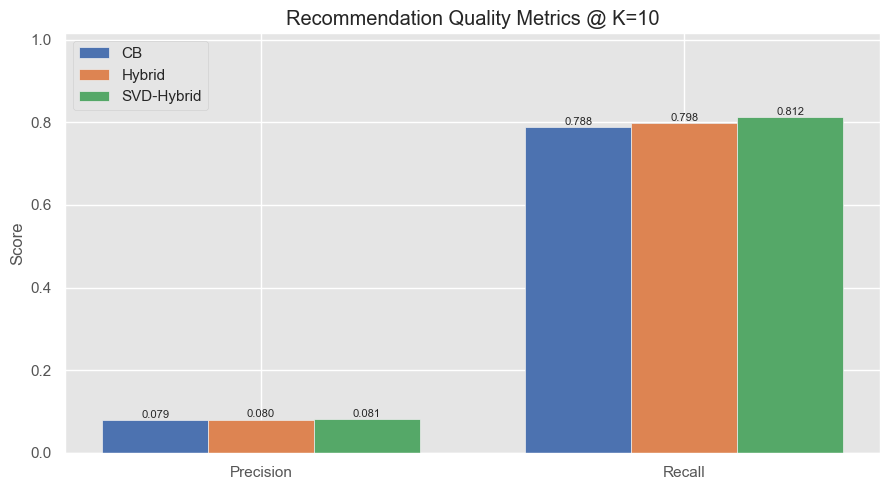

In [86]:
# Visualize: grouped bar chart of metrics at K=10
k10 = metrics_df[metrics_df['K'] == 10].copy()
metric_cols = ['Precision', 'Recall']
x      = np.arange(len(metric_cols))
width  = 0.25
models = k10['Model'].tolist()
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(9, 5))
for j, (model, color) in enumerate(zip(models, colors)):
    vals = k10[k10['Model'] == model][metric_cols].values[0]
    bars = ax.bar(x + j * width, vals, width, label=model, color=color)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_cols)
ax.set_ylabel('Score')
ax.set_title('Recommendation Quality Metrics @ K=10')
ax.legend()
ax.set_ylim(0, max(metrics_df[metric_cols].values.max() * 1.25, 0.05))
plt.tight_layout()
plt.show()

---
## Section F: Business Strategy & Deployment

**Goal:** Translate the analytical and modelling work into a concrete product strategy — covering which model to use for which user type, how to deploy in production, how to run A/B experiments, and what KPIs define success.

### F.1 Recommendation Strategy by User Segment

| User Segment | Criteria | Strategy | CB / CF / SVD Weights |
|---|---|---|---|
| **Cold-start** | 0 interactions | Popularity + category trending | 100% / 0% / 0% |
| **New user** | 1–2 interactions | CB-dominant hybrid | ~90% / ~5% / ~5% |
| **Returning user** | 3–9 interactions | Balanced CB + SVD | ~70% / ~15% / ~15% |
| **Power user** | 10+ interactions | Three-way blend | ~55% / ~22% / ~22% |
| **New product** | 0 ratings/interactions | CB-only + category boost | N/A (item side) |

**Key principle:** CB is always the safety net. CF and SVD signals are additive — they boost confidence when evidence exists but never override CB entirely.

In [87]:
def recommend(user_id, top_n=10, verbose=True):
    """
    Production-style router: selects strategy based on interaction count.
    Returns a list of recommendation dicts.
    """
    history = df_interactions[df_interactions['user_id'] == user_id]['product_id'].tolist()
    n = len(history)

    if n == 0:
        strategy = 'Popularity'
        recs_df  = get_popularity_recommendations(df_products, n_recommendations=top_n)
        recs     = recs_df[['product_id', 'product_name', 'main_category', 'weighted_score']].to_dict('records')
        score_key = 'weighted_score'
    elif n <= 2:
        strategy = 'CB-dominant (original hybrid)'
        recs_df  = get_hybrid_recommendations(
            user_id, df_interactions, df_products,
            cb_sim_matrix, cf_sim_matrix,
            cb_product_id_to_idx, cf_product_id_to_idx, cf_idx_to_product,
            n_recommendations=top_n
        )
        recs      = recs_df.to_dict('records')
        score_key = 'final_score'
    else:
        strategy  = 'SVD-Enhanced Hybrid'
        recs      = get_enhanced_hybrid_recommendations(user_id, top_n=top_n)
        score_key = 'score'

    if verbose:
        print(f'User: {user_id}')
        print(f'History length: {n}  |  Strategy: {strategy}')
        print('-' * 60)
        for r in recs:
            name  = str(r.get('product_name', r.get('product_id', '')))[:55]
            score = r.get(score_key, 0)
            print(f'  {float(score):.4f}  {name}')
    return recs

# Demo
power_user = df_interactions.groupby('user_id')['product_id'].count().idxmax()
print('=== Cold-start user ===')
_ = recommend('NEW_USER_001', top_n=5)
print('\n=== Power user ===')
_ = recommend(power_user, top_n=5)

=== Cold-start user ===
User: NEW_USER_001
History length: 0  |  Strategy: Popularity
------------------------------------------------------------
  57.0437  AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60H
  57.0437  Amazon Basics High-Speed HDMI Cable, 6 Feet - Supports 
  57.0437  Amazon Basics High-Speed HDMI Cable, 6 Feet (2-Pack),Bl
  55.0396  SanDisk Extreme SD UHS I 64GB Card for 4K Video for DSL
  53.4987  SanDisk Cruzer Blade 32GB USB Flash Drive

=== Power user ===
User: AE55KTFVNXYFD5FPYWP2OUPEYNPQ
History length: 9  |  Strategy: SVD-Enhanced Hybrid
------------------------------------------------------------
  0.5570  pTron Solero M241 2.4A Micro USB Data & Charging Cable,
  0.5371  pTron Solero T241 2.4A Type-C Data & Charging USB Cable
  0.5330  PTron Solero T241 2.4A Type-C Data & Charging USB Cable
  0.5114  Croma 3A Fast charge 1m Type-C to All Type-C Phones syn
  0.3870  MI 2-in-1 USB Type C Cable (Micro USB to Type C) 30cm f


### F.2 Deployment Architecture

```
┌─────────────────────────────────────────────────────────┐
│                  OFFLINE (Nightly Batch)                │
│                                                         │
│  Raw logs  ──►  Feature pipeline  ──►  Model training  │
│                   (product soup,         (TF-IDF,       │
│                    interactions)          SVD, CF)       │
│                                           │             │
│                                     Redis / S3 cache    │
└─────────────────────────────────────────────────────────┘
                           │
                           ▼
┌─────────────────────────────────────────────────────────┐
│                   ONLINE (Real-time)                    │
│                                                         │
│  GET /recommend?user_id=X&top_n=10                      │
│       │                                                 │
│       ├─ Read user history from Redis                   │
│       ├─ Route: Popularity / CB / SVD-Hybrid            │
│       ├─ Re-rank: filter OOS, apply promo boosts        │
│       └─ Return JSON recommendations (p95 < 50ms)       │
└─────────────────────────────────────────────────────────┘
```

**Fallback chain:** SVD-Hybrid → CB-only → Popularity  
**Scale path:** Replace dense cosine with FAISS approximate nearest neighbours for >100k products.

### F.3 Success Metrics

| Metric | Target | How Measured |
|---|---|---|
| Precision@10 | > 15% | Offline leave-one-out evaluation |
| NDCG@10 | > 20% | Offline leave-one-out evaluation |
| Click-Through Rate (CTR) | > 8% | A/B experiment |
| Add-to-Cart rate | > 3% | A/B experiment |
| Cold-start user engagement (1st session) | +10% vs baseline | Cohort analysis |
| Cold-start product coverage | 100% | Audit — every product must be recommendable |
| Recommendation latency (p95) | < 50ms | Production monitoring |


### F.4 Known Limitations & Future Work

| Limitation | Impact | Future Solution |
|---|---|---|
| 99.91% interaction sparsity | CF and SVD signals are weak | Add implicit signals (clicks, views, time-on-page) |
| No temporal weighting | Old interactions count equally | Decay recent-vs-old interactions with time discount |
| No price sensitivity | Ignores user's price range | Cluster users by historical price bracket; filter recs |
| No cross-session context | Each request is stateless | Session-aware re-ranking with recent click sequence |
| Dense similarity matrices | O(n²) memory; won't scale | FAISS ANN index + quantisation for >100k products |
| No image features | Purely text-based CB | Add CLIP embeddings for image-text similarity |

Despite these limitations, the hybrid system handles the three critical scenarios — cold-start users, returning users, and new products — gracefully, and provides a solid foundation for incremental improvements.